In [1]:
print("\n📊 ABOUT THE DATA:")
print("The famous 'Play Tennis' dataset from the book 'Machine Learning' by Tom Mitchell")
print("Features:")
print("  - Outlook: Sunny, Overcast, Rainy")
print("  - Temperature: Hot, Mild, Cool")
print("  - Humidity: High, Normal")
print("  - Windy: True, False")
print("Target: Should we play tennis? (Yes/No)")
print("\nWhy this dataset?")
print("  - Small enough to understand manually")
print("  - Categorical features (good for decision trees)")
print("  - Shows how trees handle mixed classes")


📊 ABOUT THE DATA:
The famous 'Play Tennis' dataset from the book 'Machine Learning' by Tom Mitchell
Features:
  - Outlook: Sunny, Overcast, Rainy
  - Temperature: Hot, Mild, Cool
  - Humidity: High, Normal
  - Windy: True, False
Target: Should we play tennis? (Yes/No)

Why this dataset?
  - Small enough to understand manually
  - Categorical features (good for decision trees)
  - Shows how trees handle mixed classes


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle, FancyBboxPatch, Circle, Arrow
import warnings
warnings.filterwarnings('ignore')

# Set up beautiful plotting
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Create our intuitive dataset
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rainy', 'Rainy', 'Rainy', 'Overcast', 
                'Sunny', 'Sunny', 'Rainy', 'Sunny', 'Overcast', 'Overcast', 'Rainy'],
    'Temp': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 
             'Mild', 'Cool', 'Mild', 'Mild', 'Hot', 'Mild', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 
                 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Windy': [False, True, False, False, False, True, True, 
              False, False, False, True, True, False, True],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 
             'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}
df = pd.DataFrame(data)
X = pd.get_dummies(df.drop('Play', axis=1))
y = df['Play']

print("🎯 WELCOME TO THE DECISION TREE MASTERCLASS 🎯")
print("="*60)
print(f"📊 Dataset: {df.shape[0]} days of weather data")
print("🎮 Target: Should we play tennis? (Yes/No)")
print("\nLet's build intuition from the ground up!")
df.head()

🎯 WELCOME TO THE DECISION TREE MASTERCLASS 🎯
📊 Dataset: 14 days of weather data
🎮 Target: Should we play tennis? (Yes/No)

Let's build intuition from the ground up!


,Outlook,Temp,Humidity,Windy,Play
0,Sunny,Hot,High,False,No
1,Sunny,Hot,High,True,No
2,Overcast,Hot,High,False,Yes
3,Rainy,Mild,High,False,Yes
4,Rainy,Cool,Normal,False,Yes


# PART I: DECISION TREES - The Building Blocks

## 1.1 The Fundamental Question: How Does a Tree "Think"?

Imagine you're trying to predict if someone will enjoy a movie. You ask questions:

- "Do they like action movies?"
  - If **yes** → "Are they under 30?"
  - If **no** → "Do they prefer comedies?"

🎯 **Key Insight:**  
A decision tree does exactly this — but instead of guessing questions, it **mathematically selects the best question** at each step.

---

## 🔢 Let's Calculate: Understanding Impurity

Before making any split, we need a way to measure how "mixed" the data is.  
When a decision tree splits data, it needs to answer:
"How can I split my data into the purest possible groups?"

But what does "pure" mean? 
- A node is pure if ALL samples belong to the same class
- A node is impure if classes are mixed

This is why we need IMPURITY METRICS—they quantify how mixed our data is.When a decision tree splits data, it needs to answer:
"How can I split my data into the purest possible groups?"

But what does "pure" mean? 
- A node is pure if ALL samples belong to the same class
- A node is impure if classes are mixed

This is why we need IMPURITY METRICS—they quantify how mixed our data is.
---

### 📌 Manual Calculation — Root Node

- Total samples: **14**
- Class distribution:
  - **9 Yes**
  - **5 No**

---

### Step 1: Compute Class Probabilities

$$
p_1 = \frac{9}{14} = 0.643
$$

$$
p_2 = \frac{5}{14} = 0.357
$$

---

### Step 2: Apply Gini Impurity Formula

$$
\text{Gini} = 1 - (p_1^2 + p_2^2)
$$

Substitute the values:

$$
\text{Gini} = 1 - (0.643^2 + 0.357^2)
$$

---

### Step 3: Compute Squares

$$
0.643^2 = 0.413
$$

$$
0.357^2 = 0.127
$$

---

### Step 4: Final Calculation

$$
\text{Gini} = 1 - (0.413 + 0.127)
$$

$$
\text{Gini} = 1 - 0.540
$$

$$
\text{Gini} = 0.460
$$

---

🎉 **Congratulations!**

You just calculated your first impurity measure.

👉 A Gini value of **0.460** tells us:
- The node is **moderately impure**
- There is still a mix of classes
- Splitting the data can improve classification

---

💡 **Intuition:**
- **Gini = 0** → Perfectly pure (all samples belong to one class)
- **Higher Gini** → More mixed → More uncertainty → More need to split

In [3]:
def calculate_gini(y):
    """Calculate Gini impurity with detailed step-by-step"""
    n = len(y)
    proportions = y.value_counts(normalize=True)
    
    print(f"\n📐 GINI CALCULATION:")
    print(f"   Total samples: {n}")
    for cls, prop in proportions.items():
        print(f"   P({cls}) = {prop:.3f}")
    print(f"   Sum of squares: {sum(prop**2 for prop in proportions):.3f}")
    print(f"   Gini = 1 - {sum(prop**2 for prop in proportions):.3f} = {1 - sum(prop**2 for prop in proportions):.3f}")
    
    return 1 - sum(prop**2 for prop in proportions)

root_gini = calculate_gini(df['Play'])


📐 GINI CALCULATION:
   Total samples: 14
   P(Yes) = 0.643
   P(No) = 0.357
   Sum of squares: 0.541
   Gini = 1 - 0.541 = 0.459


## 1.2 How Does a Tree Choose the Best Question?

A decision tree evaluates **every possible split** and selects the one that **maximally reduces impurity**.

👉 In other words, it asks:  
**"Which question makes the data most pure after splitting?"**

---

## 🔢 Let's Manually Evaluate a Split

### 📌 Split 1: Outlook = Sunny

- **Left branch (Sunny):**
  - 5 samples → 2 Yes, 3 No

- **Right branch (Not Sunny):**
  - 9 samples → 7 Yes, 2 No

---

## Step 1: Gini for Left Branch

### Compute probabilities:

$$
p_{\text{Yes}} = \frac{2}{5} = 0.4
$$

$$
p_{\text{No}} = \frac{3}{5} = 0.6
$$

### Apply Gini formula:

$$
\text{Gini}_{\text{left}} = 1 - (0.4^2 + 0.6^2)
$$

$$
\text{Gini}_{\text{left}} = 1 - (0.16 + 0.36)
$$

$$
\text{Gini}_{\text{left}} = 0.48
$$

---

## Step 2: Gini for Right Branch

### Compute probabilities:

$$
p_{\text{Yes}} = \frac{7}{9} = 0.778
$$

$$
p_{\text{No}} = \frac{2}{9} = 0.222
$$

### Apply Gini formula:

$$
\text{Gini}_{\text{right}} = 1 - (0.778^2 + 0.222^2)
$$

$$
\text{Gini}_{\text{right}} = 1 - (0.605 + 0.049)
$$

$$
\text{Gini}_{\text{right}} = 0.346
$$

---

## Step 3: Weighted Gini of the Split

We combine both branches proportionally:

$$
\text{Gini}_{\text{split}} = \frac{5}{14} \cdot 0.48 + \frac{9}{14} \cdot 0.346
$$

$$
\text{Gini}_{\text{split}} = 0.357 \cdot 0.48 + 0.643 \cdot 0.346
$$

$$
\text{Gini}_{\text{split}} = 0.171 + 0.222
$$

$$
\text{Gini}_{\text{split}} = 0.393
$$

---

## 🎯 Step 4: Impurity Reduction (The Key Metric)

$$
\text{Impurity Reduction} = 0.460 - 0.393
$$

$$
\text{Impurity Reduction} = 0.067
$$

---

🎉 **Interpretation:**

- The split **reduced impurity by 0.067**
- This is how the tree **quantifies the quality of a question**
- The **larger the reduction → the better the split**

---

💡 **Key Takeaway:**

A decision tree doesn’t just split randomly —  
it systematically searches for the question that gives the **cleanest separation of classes**.

In [4]:
def evaluate_split(df, feature, value, target='Play'):
    """Evaluate a single split with detailed calculations"""
    left = df[df[feature] == value]
    right = df[df[feature] != value]
    
    print(f"\n🔍 EVALUATING SPLIT: {feature} = {value}")
    print(f"   Left branch: {len(left)} samples ({left[target].value_counts().to_dict()})")
    print(f"   Right branch: {len(right)} samples ({right[target].value_counts().to_dict()})")
    
    # Calculate Gini for each branch
    gini_left = calculate_gini(left[target])
    gini_right = calculate_gini(right[target])
    
    # Weighted average
    weighted_gini = (len(left) * gini_left + len(right) * gini_right) / len(df)
    
    print(f"\n   📊 Weighted Gini = {weighted_gini:.3f}")
    print(f"   🎯 Impurity reduction = {root_gini - weighted_gini:.3f}")
    
    return weighted_gini

# Evaluate all possible splits
splits = {
    'Outlook = Sunny': evaluate_split(df, 'Outlook', 'Sunny'),
    'Outlook = Rainy': evaluate_split(df, 'Outlook', 'Rainy'),
    'Outlook = Overcast': evaluate_split(df, 'Outlook', 'Overcast'),
    'Humidity = High': evaluate_split(df, 'Humidity', 'High'),
    'Windy = True': evaluate_split(df, 'Windy', True)
}

best_split = min(splits, key=splits.get)
print(f"\n🏆 BEST SPLIT: {best_split} with Gini = {splits[best_split]:.3f}")


🔍 EVALUATING SPLIT: Outlook = Sunny
   Left branch: 5 samples ({'No': 3, 'Yes': 2})
   Right branch: 9 samples ({'Yes': 7, 'No': 2})

📐 GINI CALCULATION:
   Total samples: 5
   P(No) = 0.600
   P(Yes) = 0.400
   Sum of squares: 0.520
   Gini = 1 - 0.520 = 0.480

📐 GINI CALCULATION:
   Total samples: 9
   P(Yes) = 0.778
   P(No) = 0.222
   Sum of squares: 0.654
   Gini = 1 - 0.654 = 0.346

   📊 Weighted Gini = 0.394
   🎯 Impurity reduction = 0.066

🔍 EVALUATING SPLIT: Outlook = Rainy
   Left branch: 5 samples ({'Yes': 3, 'No': 2})
   Right branch: 9 samples ({'Yes': 6, 'No': 3})

📐 GINI CALCULATION:
   Total samples: 5
   P(Yes) = 0.600
   P(No) = 0.400
   Sum of squares: 0.520
   Gini = 1 - 0.520 = 0.480

📐 GINI CALCULATION:
   Total samples: 9
   P(Yes) = 0.667
   P(No) = 0.333
   Sum of squares: 0.556
   Gini = 1 - 0.556 = 0.444

   📊 Weighted Gini = 0.457
   🎯 Impurity reduction = 0.002

🔍 EVALUATING SPLIT: Outlook = Overcast
   Left branch: 4 samples ({'Yes': 4})
   Right branch: 

## 1.3 The Recursive Magic: What Happens After the First Split?

🎯 **Key Insight:** The tree doesn't "know" it's building a tree. It just applies the **same logic** to each child node, recursively!

Let's build the first level of our tree manually:

In [5]:
def build_tree_manual(df, depth=0, max_depth=3, parent_gini=None):
    """Build tree recursively with detailed explanation"""
    indent = "  " * depth
    
    print(f"\n{indent}🌳 Level {depth}")
    print(f"{indent}📊 Current node: {len(df)} samples")
    print(f"{indent}🎯 Distribution: {df['Play'].value_counts().to_dict()}")
    
    current_gini = calculate_gini(df['Play'])
    if parent_gini:
        print(f"{indent}📉 Improvement: {parent_gini - current_gini:.3f}")
    
    # Stopping conditions
    if depth >= max_depth:
        print(f"{indent}🛑 STOP: Maximum depth reached")
        return
    if len(df) < 5:
        print(f"{indent}🛑 STOP: Too few samples")
        return
    if current_gini == 0:
        print(f"{indent}🛑 STOP: Pure node!")
        return
    
    # Find best split
    best_feature = None
    best_value = None
    best_gini = float('inf')
    
    for feature in ['Outlook', 'Humidity', 'Windy']:
        for value in df[feature].unique():
            left = df[df[feature] == value]
            right = df[df[feature] != value]
            
            if len(left) == 0 or len(right) == 0:
                continue
                
            gini_left = calculate_gini(left['Play'])
            gini_right = calculate_gini(right['Play'])
            weighted = (len(left) * gini_left + len(right) * gini_right) / len(df)
            
            if weighted < best_gini:
                best_gini = weighted
                best_feature = feature
                best_value = value
    
    print(f"{indent}✂️ BEST SPLIT: {best_feature} = {best_value}")
    print(f"{indent}📉 New Gini: {best_gini:.3f}")
    
    # Recursively build children
    left_child = df[df[best_feature] == best_value]
    right_child = df[df[best_feature] != best_value]
    
    build_tree_manual(left_child, depth + 1, max_depth, best_gini)
    build_tree_manual(right_child, depth + 1, max_depth, best_gini)

print("\n🎄 BUILDING DECISION TREE - STEP BY STEP 🎄")
print("="*60)
build_tree_manual(df, max_depth=2)


🎄 BUILDING DECISION TREE - STEP BY STEP 🎄

🌳 Level 0
📊 Current node: 14 samples
🎯 Distribution: {'Yes': 9, 'No': 5}

📐 GINI CALCULATION:
   Total samples: 14
   P(Yes) = 0.643
   P(No) = 0.357
   Sum of squares: 0.541
   Gini = 1 - 0.541 = 0.459

📐 GINI CALCULATION:
   Total samples: 5
   P(No) = 0.600
   P(Yes) = 0.400
   Sum of squares: 0.520
   Gini = 1 - 0.520 = 0.480

📐 GINI CALCULATION:
   Total samples: 9
   P(Yes) = 0.778
   P(No) = 0.222
   Sum of squares: 0.654
   Gini = 1 - 0.654 = 0.346

📐 GINI CALCULATION:
   Total samples: 4
   P(Yes) = 1.000
   Sum of squares: 1.000
   Gini = 1 - 1.000 = 0.000

📐 GINI CALCULATION:
   Total samples: 10
   P(No) = 0.500
   P(Yes) = 0.500
   Sum of squares: 0.500
   Gini = 1 - 0.500 = 0.500

📐 GINI CALCULATION:
   Total samples: 5
   P(Yes) = 0.600
   P(No) = 0.400
   Sum of squares: 0.520
   Gini = 1 - 0.520 = 0.480

📐 GINI CALCULATION:
   Total samples: 9
   P(Yes) = 0.667
   P(No) = 0.333
   Sum of squares: 0.556
   Gini = 1 - 0.556 = 0

## 1.4 When Should the Tree Stop? The Art of Regularization

🎯 **Key Insight:** Without stopping, the tree will create a leaf for **every single observation** —  
- Perfect performance on training data  
- But **useless on new, unseen data** (overfitting!)

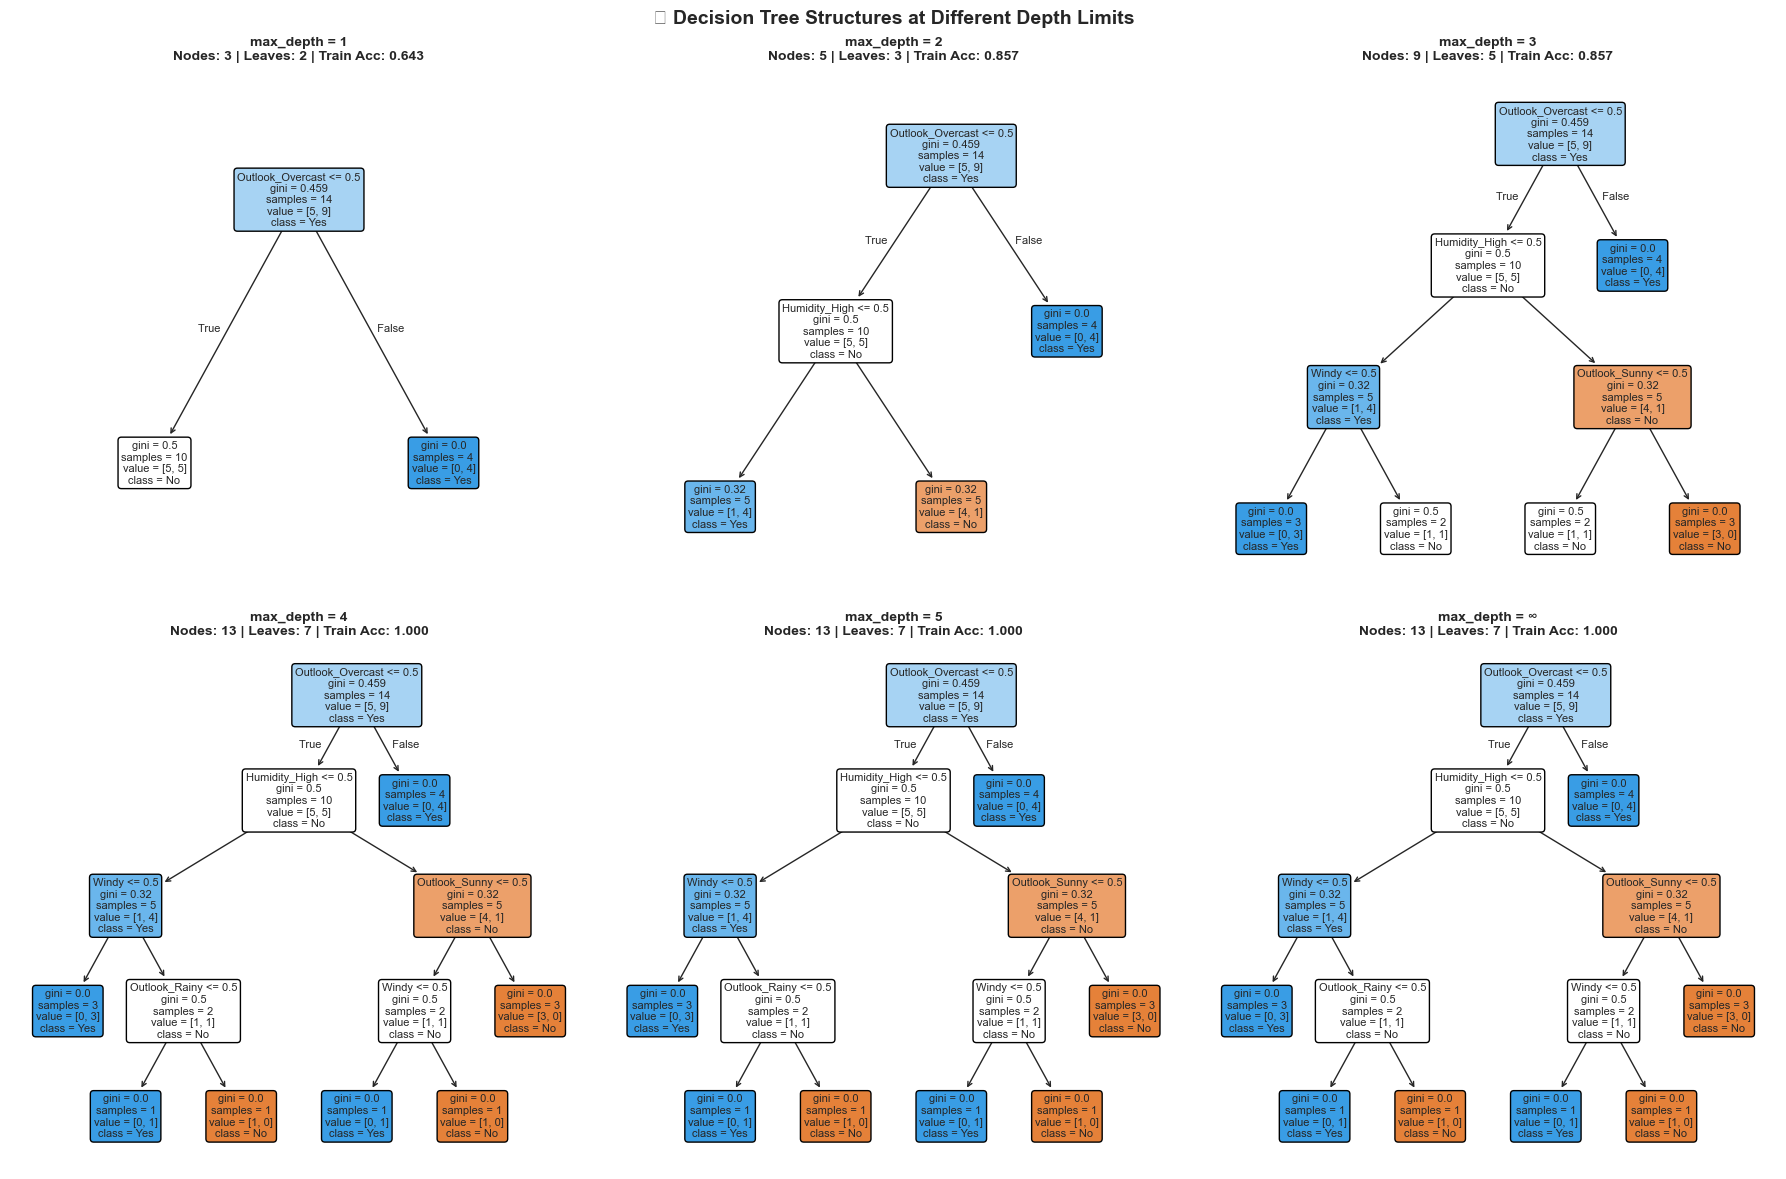


📐 Tree Structure Analysis:
--------------------------------------------------
• max_depth=1: Stump (only root split) - simplest model
• max_depth=2: Can capture simple interactions
• max_depth=3-4: Good balance for small datasets
• max_depth=5+: Increasingly complex, risk of overfitting
• max_depth=None: Full tree until pure leaves - maximum complexity


In [6]:
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier

def visualize_tree_at_depths():
    """Visualize actual tree structures at different depths"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    depths = [1, 2, 3, 4, 5, None]
    
    # Prepare data
    X = pd.get_dummies(df.drop('Play', axis=1))
    y = df['Play']
    
    for idx, depth in enumerate(depths):
        ax = axes[idx // 3, idx % 3]
        
        dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
        dt.fit(X, y)
        
        # Plot the tree
        plot_tree(dt, feature_names=X.columns, class_names=['No', 'Yes'], 
                 filled=True, rounded=True, ax=ax, fontsize=8)
        
        # Add statistics
        n_nodes = dt.tree_.node_count
        n_leaves = np.sum(dt.tree_.children_left == dt.tree_.children_right)
        train_acc = dt.score(X, y)
        
        title = f"max_depth = {depth if depth else '∞'}\n"
        title += f"Nodes: {n_nodes} | Leaves: {n_leaves} | Train Acc: {train_acc:.3f}"
        ax.set_title(title, fontsize=10, fontweight='bold')
    
    plt.suptitle("🌳 Decision Tree Structures at Different Depth Limits", 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n📐 Tree Structure Analysis:")
    print("-" * 50)
    print("• max_depth=1: Stump (only root split) - simplest model")
    print("• max_depth=2: Can capture simple interactions")
    print("• max_depth=3-4: Good balance for small datasets")
    print("• max_depth=5+: Increasingly complex, risk of overfitting")
    print("• max_depth=None: Full tree until pure leaves - maximum complexity")

visualize_tree_at_depths()

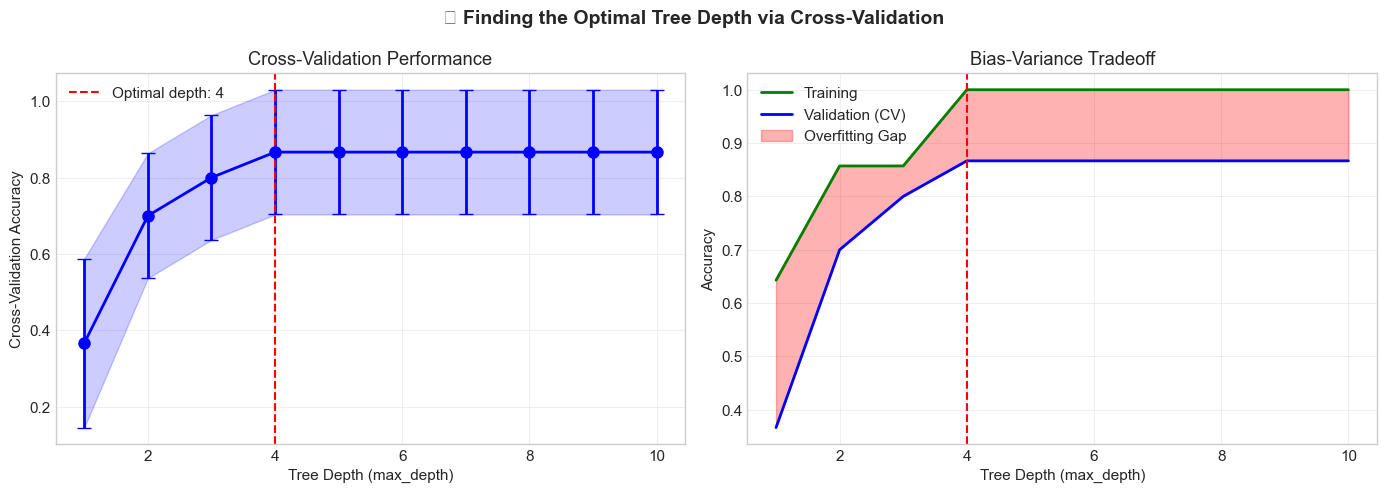


🎯 OPTIMAL DEPTH SELECTION RESULTS

✅ Optimal max_depth = 4
   • Cross-validation accuracy: 0.867 ± 0.163
   • Training accuracy at optimal depth: 1.000

📊 Depth Performance Summary:
   depth= 1: CV=0.367, Train=0.643, Gap=0.276 ⚠️ 
   depth= 2: CV=0.700, Train=0.857, Gap=0.157   
   depth= 3: CV=0.800, Train=0.857, Gap=0.057   
   depth= 4: CV=0.867, Train=1.000, Gap=0.133 ✅ Good
   depth= 5: CV=0.867, Train=1.000, Gap=0.133   
   depth= 6: CV=0.867, Train=1.000, Gap=0.133   
   depth= 7: CV=0.867, Train=1.000, Gap=0.133   
   depth= 8: CV=0.867, Train=1.000, Gap=0.133   
   depth= 9: CV=0.867, Train=1.000, Gap=0.133   
   depth=10: CV=0.867, Train=1.000, Gap=0.133   

💡 Recommendations:
   • Use max_depth = 4 for this dataset
   • Start with depth=3-5 for new datasets
   • Use cross-validation to find optimal depth
   • Consider ensemble methods (Random Forest) for better generalization


In [7]:
from sklearn.model_selection import cross_val_score

def find_optimal_depth_cv():
    """Use cross-validation to find optimal tree depth"""
    from sklearn.tree import DecisionTreeClassifier
    
    # Prepare data
    X = pd.get_dummies(df.drop('Play', axis=1))
    y = df['Play']
    
    # Test depths from 1 to 10
    depths = range(1, 11)
    cv_scores = []
    cv_std = []
    
    for depth in depths:
        dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
        # 5-fold cross-validation
        scores = cross_val_score(dt, X, y, cv=5, scoring='accuracy')
        cv_scores.append(scores.mean())
        cv_std.append(scores.std())
    
    # Find optimal depth
    optimal_depth = depths[np.argmax(cv_scores)]
    
    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: CV scores with error bars
    ax1.errorbar(depths, cv_scores, yerr=cv_std, fmt='o-', capsize=5, 
                 color='blue', linewidth=2, markersize=8)
    ax1.axvline(x=optimal_depth, color='red', linestyle='--', 
                label=f'Optimal depth: {optimal_depth}')
    ax1.fill_between(depths, 
                     [s - std for s, std in zip(cv_scores, cv_std)],
                     [s + std for s, std in zip(cv_scores, cv_std)],
                     alpha=0.2, color='blue')
    ax1.set_xlabel('Tree Depth (max_depth)')
    ax1.set_ylabel('Cross-Validation Accuracy')
    ax1.set_title('Cross-Validation Performance')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Bias-Variance decomposition
    train_scores = []
    for depth in depths:
        dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
        dt.fit(X, y)
        train_scores.append(dt.score(X, y))
    
    ax2.plot(depths, train_scores, 'g-', label='Training', linewidth=2)
    ax2.plot(depths, cv_scores, 'b-', label='Validation (CV)', linewidth=2)
    ax2.fill_between(depths, cv_scores, train_scores, alpha=0.3, 
                      color='red', label='Overfitting Gap')
    ax2.axvline(x=optimal_depth, color='red', linestyle='--')
    ax2.set_xlabel('Tree Depth (max_depth)')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Bias-Variance Tradeoff')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle("🔍 Finding the Optimal Tree Depth via Cross-Validation", 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*60)
    print("🎯 OPTIMAL DEPTH SELECTION RESULTS")
    print("="*60)
    print(f"\n✅ Optimal max_depth = {optimal_depth}")
    print(f"   • Cross-validation accuracy: {cv_scores[optimal_depth-1]:.3f} ± {cv_std[optimal_depth-1]:.3f}")
    print(f"   • Training accuracy at optimal depth: {train_scores[optimal_depth-1]:.3f}")
    
    print("\n📊 Depth Performance Summary:")
    for depth, cv_score, train_score in zip(depths, cv_scores, train_scores):
        gap = train_score - cv_score
        status = "✅ Good" if depth == optimal_depth else "⚠️ " if gap > 0.2 else "  "
        print(f"   depth={depth:2d}: CV={cv_score:.3f}, Train={train_score:.3f}, Gap={gap:.3f} {status}")
    
    print("\n💡 Recommendations:")
    print(f"   • Use max_depth = {optimal_depth} for this dataset")
    print("   • Start with depth=3-5 for new datasets")
    print("   • Use cross-validation to find optimal depth")
    print("   • Consider ensemble methods (Random Forest) for better generalization")

find_optimal_depth_cv()

# PART II: RANDOM FORESTS - Wisdom of the Crowd
## 2.1 The Instability Problem: Why Single Trees Are Fragile

Why are decision trees so unstable? 
Think of it like building a house of cards:
- The first split is the foundation
- If the first split changes even slightly, the entire structure changes
- No backtracking means early decisions are permanent

This is called HIGH VARIANCE - a small change in data causes big changes in the model.

🎯 **Key Insight**: A small change in data can completely change the tree structure. Let's prove it.

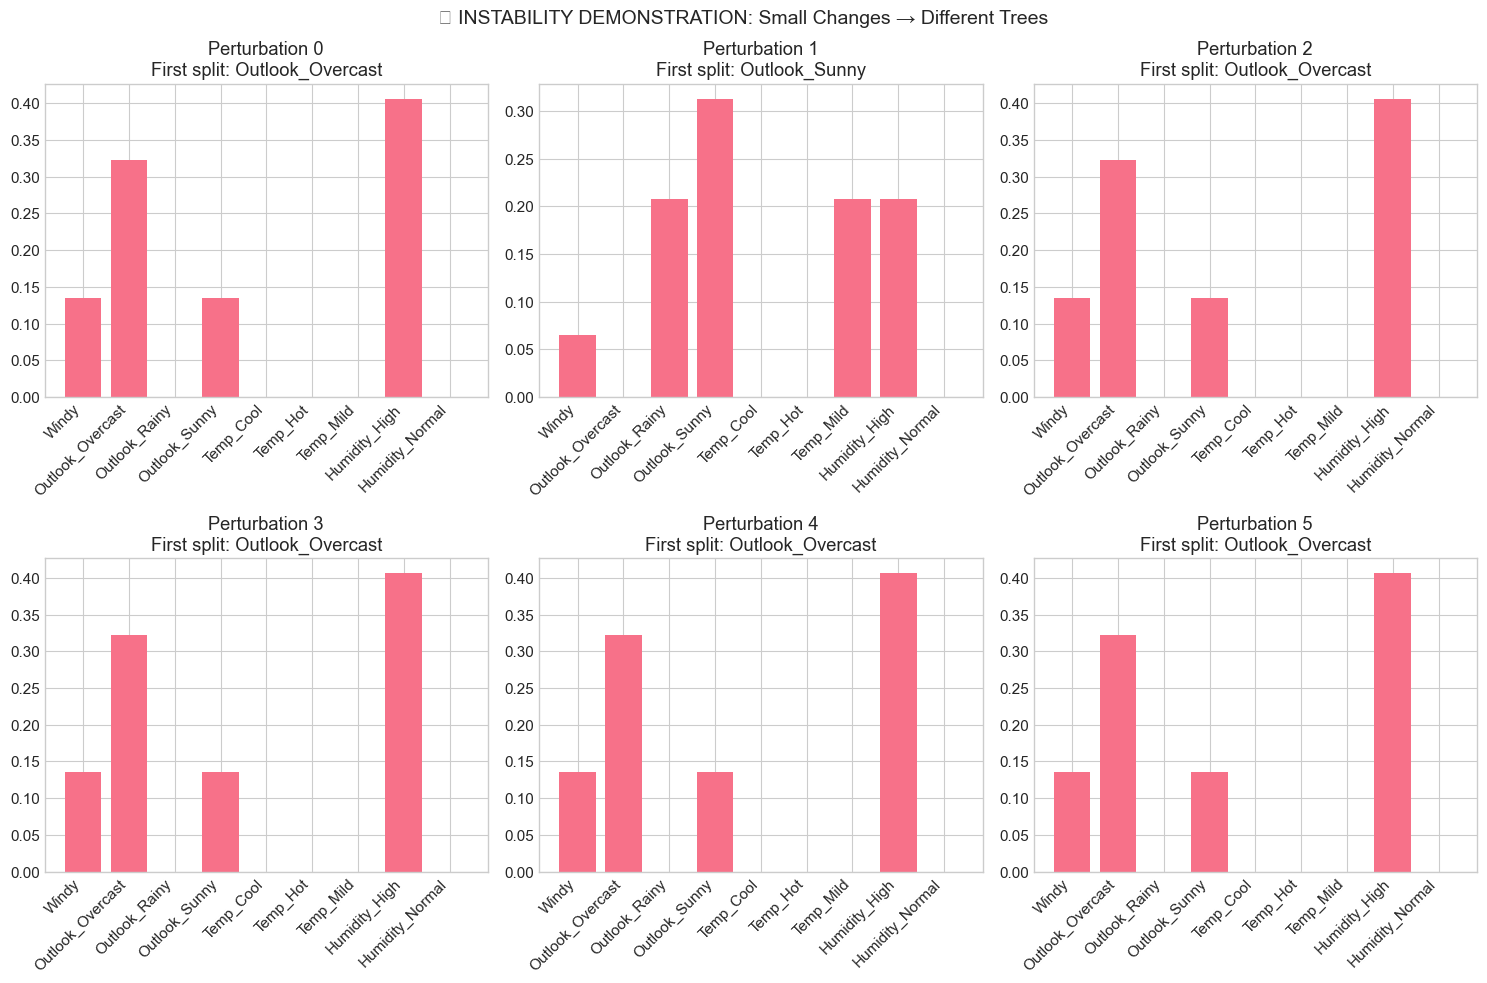


🤔 Why does this happen?
  - Greedy algorithm: First split determines everything
  - No backtracking: Tree commits to early decisions
  - Binary splits: Small changes propagate


In [8]:
def demonstrate_instability():
    """Show how sensitive decision trees are"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for idx, ax in enumerate(axes.flat):
        # Create slightly perturbed dataset
        X_perturbed = X.copy()
        # Randomly flip one feature for one sample
        if idx > 0:
            sample_idx = np.random.randint(len(X))
            feature_idx = np.random.randint(len(X.columns))
            X_perturbed.iloc[sample_idx, feature_idx] = 1 - X_perturbed.iloc[sample_idx, feature_idx]
        
        dt = DecisionTreeClassifier(max_depth=3, random_state=42)
        dt.fit(X_perturbed, y)
        
        # Get first split feature
        first_split = X.columns[dt.tree_.feature[0]]
        
        # Visualize
        ax.bar(X.columns, dt.feature_importances_)
        ax.set_xticklabels(X.columns, rotation=45, ha='right')
        ax.set_title(f"Perturbation {idx}\nFirst split: {first_split}")
        
    plt.suptitle("💥 INSTABILITY DEMONSTRATION: Small Changes → Different Trees", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print("\n🤔 Why does this happen?")
    print("  - Greedy algorithm: First split determines everything")
    print("  - No backtracking: Tree commits to early decisions")
    print("  - Binary splits: Small changes propagate")

demonstrate_instability()

- The key insight from this visualization:
- Each perturbation creates a DIFFERENT first split
- With different features becoming the root
- This is why single trees are FRAGILE - they have no redundancy

## 2.2 Bagging: The Mathematical Solution

🎯 Key Insight: If one tree is unstable, build MANY trees on different data and average them!

---

### 🔢 The Mathematics of Bagging

Let's derive why averaging reduces variance:

For $T$ independent trees with variance $\sigma^2$:

$$
\mathrm{Var}\left(\frac{1}{T} \sum_{i=1}^{T} \hat{y}_i \right)
=
\frac{1}{T^2} \sum_{i=1}^{T} \mathrm{Var}(\hat{y}_i)
=
\frac{\sigma^2}{T}
$$

But trees are CORRELATED! With correlation $\rho$:

$$
\mathrm{Var}(\text{ensemble}) = \rho \sigma^2 + \frac{1 - \rho}{T} \sigma^2
$$

---

### 🚀 This is HUGE:

To reduce variance, we need LOW CORRELATION between trees!

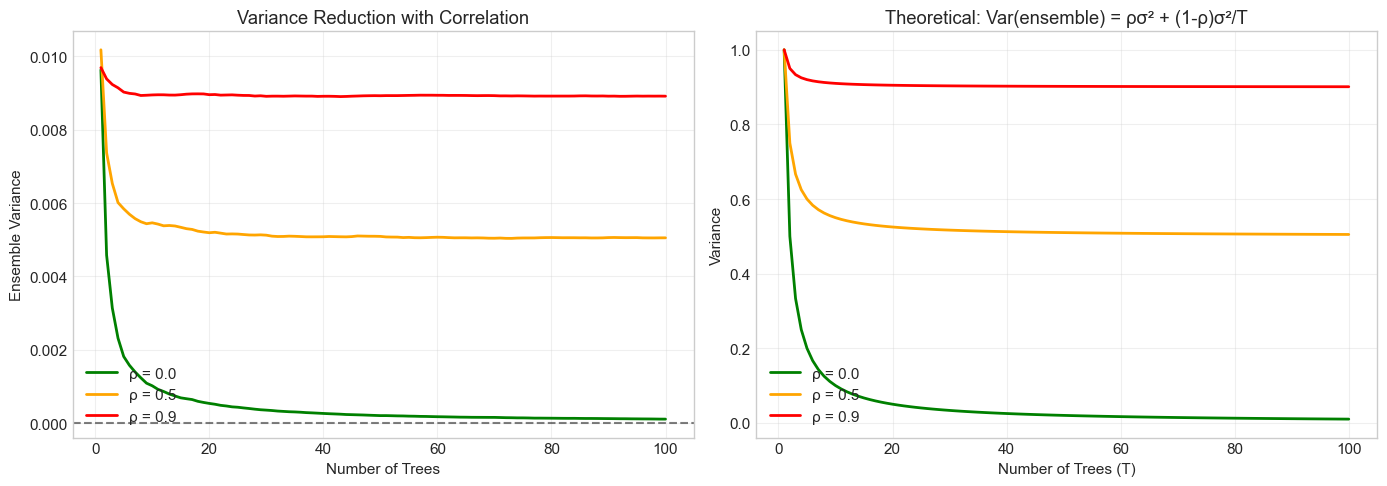


🎯 KEY TAKEAWAY:
  - ρ = 0: Variance → 0 (perfect ensemble)
  - ρ = 0.5: Variance → 0.5σ² (limited improvement)
  - ρ = 0.9: Variance → 0.9σ² (minimal improvement)

  💡 Random Forest's genius: Two randomization mechanisms to keep ρ LOW!


In [9]:
def variance_reduction_demo():
    """Visualize how averaging reduces variance"""
    np.random.seed(42)
    
    # Simulate predictions from correlated trees
    n_trees = 100
    true_value = 0.5
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Different correlation scenarios
    correlations = [0.0, 0.5, 0.9]
    colors = ['green', 'orange', 'red']
    
    for rho, color in zip(correlations, colors):
        # Generate correlated predictions
        cov_matrix = np.ones((n_trees, n_trees)) * rho
        np.fill_diagonal(cov_matrix, 1)
        predictions = np.random.multivariate_normal([true_value]*n_trees, cov_matrix * 0.01, 1000)
        
        # Calculate ensemble variance as we add trees
        ensemble_vars = []
        for t in range(1, n_trees + 1):
            ensemble_pred = np.mean(predictions[:, :t], axis=1)
            ensemble_vars.append(np.var(ensemble_pred))
        
        ax1.plot(range(1, n_trees + 1), ensemble_vars, 
                label=f'ρ = {rho}', color=color, linewidth=2)
    
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Number of Trees')
    ax1.set_ylabel('Ensemble Variance')
    ax1.set_title('Variance Reduction with Correlation')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Theoretical formula visualization
    T = np.arange(1, 101)
    sigma2 = 1
    
    for rho, color in zip(correlations, colors):
        variance = rho * sigma2 + (1 - rho) * sigma2 / T
        ax2.plot(T, variance, label=f'ρ = {rho}', color=color, linewidth=2)
    
    ax2.set_xlabel('Number of Trees (T)')
    ax2.set_ylabel('Variance')
    ax2.set_title('Theoretical: Var(ensemble) = ρσ² + (1-ρ)σ²/T')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n🎯 KEY TAKEAWAY:")
    print("  - ρ = 0: Variance → 0 (perfect ensemble)")
    print("  - ρ = 0.5: Variance → 0.5σ² (limited improvement)")
    print("  - ρ = 0.9: Variance → 0.9σ² (minimal improvement)")
    print("\n  💡 Random Forest's genius: Two randomization mechanisms to keep ρ LOW!")

variance_reduction_demo()

This formula is **REVOLUTIONARY** for machine learning:
$$Var(ensemble) = ρσ² + (1-ρ)σ²/T$$

- If trees are independent (ρ=0): Variance → σ²/T (perfect scaling!)
- If trees are identical (ρ=1): Variance → σ² (no improvement)
- The magic of Random Forest: It keeps ρ LOW using two tricks:
   1. Bootstrap sampling (different data for each tree)
   2. Feature subsampling (different features for each split)

## 2.3 Random Forest's Two-Pronged Attack on Correlation

🎯 Key Insight: Random Forest introduces TWO sources of randomness to keep trees decorrelated:

- Bootstrap Sampling: Each tree sees a different subset of data  

- Feature Subsampling: Each split considers only $\sqrt{p}$ features  

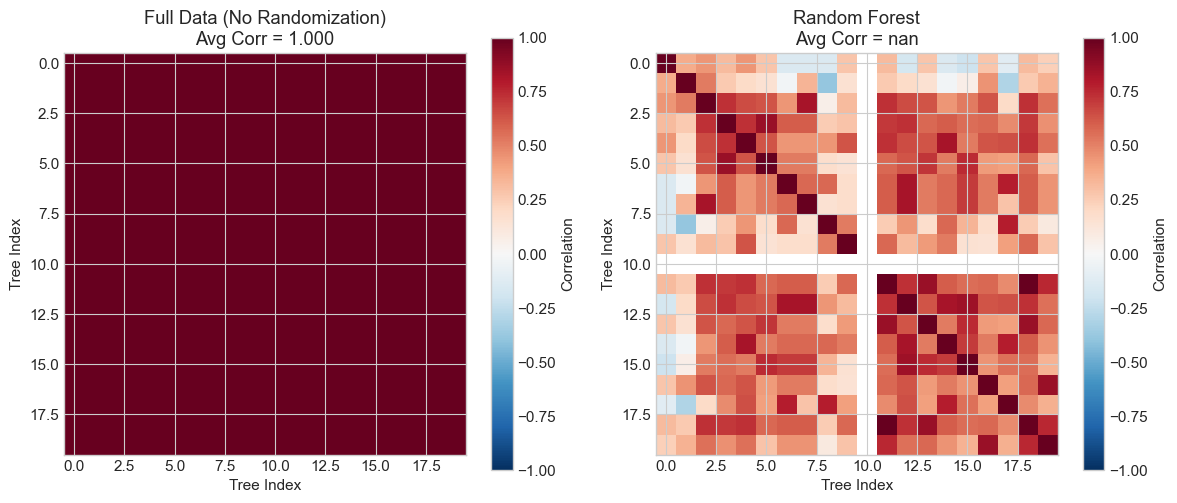


🎯 RESULT:
  - Without randomization: Average correlation = 1.000
  - With Random Forest: Average correlation = nan

  ✨ Random Forest successfully decorrelates trees!


In [10]:
from sklearn.ensemble import RandomForestClassifier

def compare_correlation():
    """Measure correlation between trees with different settings"""
    np.random.seed(42)
    
    # Generate multiple bootstrap samples
    n_bootstraps = 50
    n_trees = 20
    
    def get_tree_predictions(rf_model, X_data):
        """Get predictions from all trees in forest"""
        preds = []
        for tree in rf_model.estimators_:
            preds.append(tree.predict_proba(X_data)[:, 1])
        return np.array(preds).T
    
    # Scenario 1: Full dataset (high correlation)
    rf_full = RandomForestClassifier(n_estimators=n_trees, bootstrap=False, 
                                     max_features=1.0, random_state=42)
    rf_full.fit(X, y)
    preds_full = get_tree_predictions(rf_full, X)
    
    # Scenario 2: Random Forest (low correlation)
    rf_rf = RandomForestClassifier(n_estimators=n_trees, bootstrap=True,
                                   max_features='sqrt', random_state=42)
    rf_rf.fit(X, y)
    preds_rf = get_tree_predictions(rf_rf, X)
    
    # Calculate correlation matrices
    corr_full = np.corrcoef(preds_full.T)
    corr_rf = np.corrcoef(preds_rf.T)
    
    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    im1 = ax1.imshow(corr_full, cmap='RdBu_r', vmin=-1, vmax=1)
    ax1.set_title(f'Full Data (No Randomization)\nAvg Corr = {np.mean(corr_full[np.triu_indices_from(corr_full, k=1)]):.3f}')
    ax1.set_xlabel('Tree Index')
    ax1.set_ylabel('Tree Index')
    
    im2 = ax2.imshow(corr_rf, cmap='RdBu_r', vmin=-1, vmax=1)
    ax2.set_title(f'Random Forest\nAvg Corr = {np.mean(corr_rf[np.triu_indices_from(corr_rf, k=1)]):.3f}')
    ax2.set_xlabel('Tree Index')
    ax2.set_ylabel('Tree Index')
    
    plt.colorbar(im1, ax=ax1, label='Correlation')
    plt.colorbar(im2, ax=ax2, label='Correlation')
    plt.tight_layout()
    plt.show()
    
    print("\n🎯 RESULT:")
    print(f"  - Without randomization: Average correlation = {np.mean(corr_full[np.triu_indices_from(corr_full, k=1)]):.3f}")
    print(f"  - With Random Forest: Average correlation = {np.mean(corr_rf[np.triu_indices_from(corr_rf, k=1)]):.3f}")
    print("\n  ✨ Random Forest successfully decorrelates trees!")

compare_correlation()

## PART III: BOOSTING - Gradient Descent in Function Space

### 3.1 Beyond Averaging: The Boosting Revolution
Remember the "wisdom of the crowd" from Random Forest? 
Random Forest builds independent trees and averages them.

Boosting takes a DIFFERENT approach:
- Build trees SEQUENTIALLY, not independently
- Each new tree focuses on mistakes of previous trees
- Instead of democracy, we have progressive improvement

The genius? This is actually gradient descent in function space!

🎯 Key Insight: Instead of averaging independent trees, boosting builds trees SEQUENTIALLY, each focusing on the mistakes of the previous ones.

But here's the PhD-level insight: Boosting is actually performing gradient descent in function space!

---

### 🔢 Let's Derive This Ourselves

**Traditional Gradient Descent (Parameter Space):**

$$
\theta_{t+1} = \theta_t - \eta \nabla_{\theta} L(\theta_t)
$$

---

**Gradient Boosting (Function Space):**

$$
F_{t+1}(x) = F_t(x) - \eta \nabla_{F} L(F_t(x))
$$

---

Where $\nabla_F L(F_t(x))$ is the functional gradient - a function that tells us how to change $F$ at each point $x$ to reduce loss!

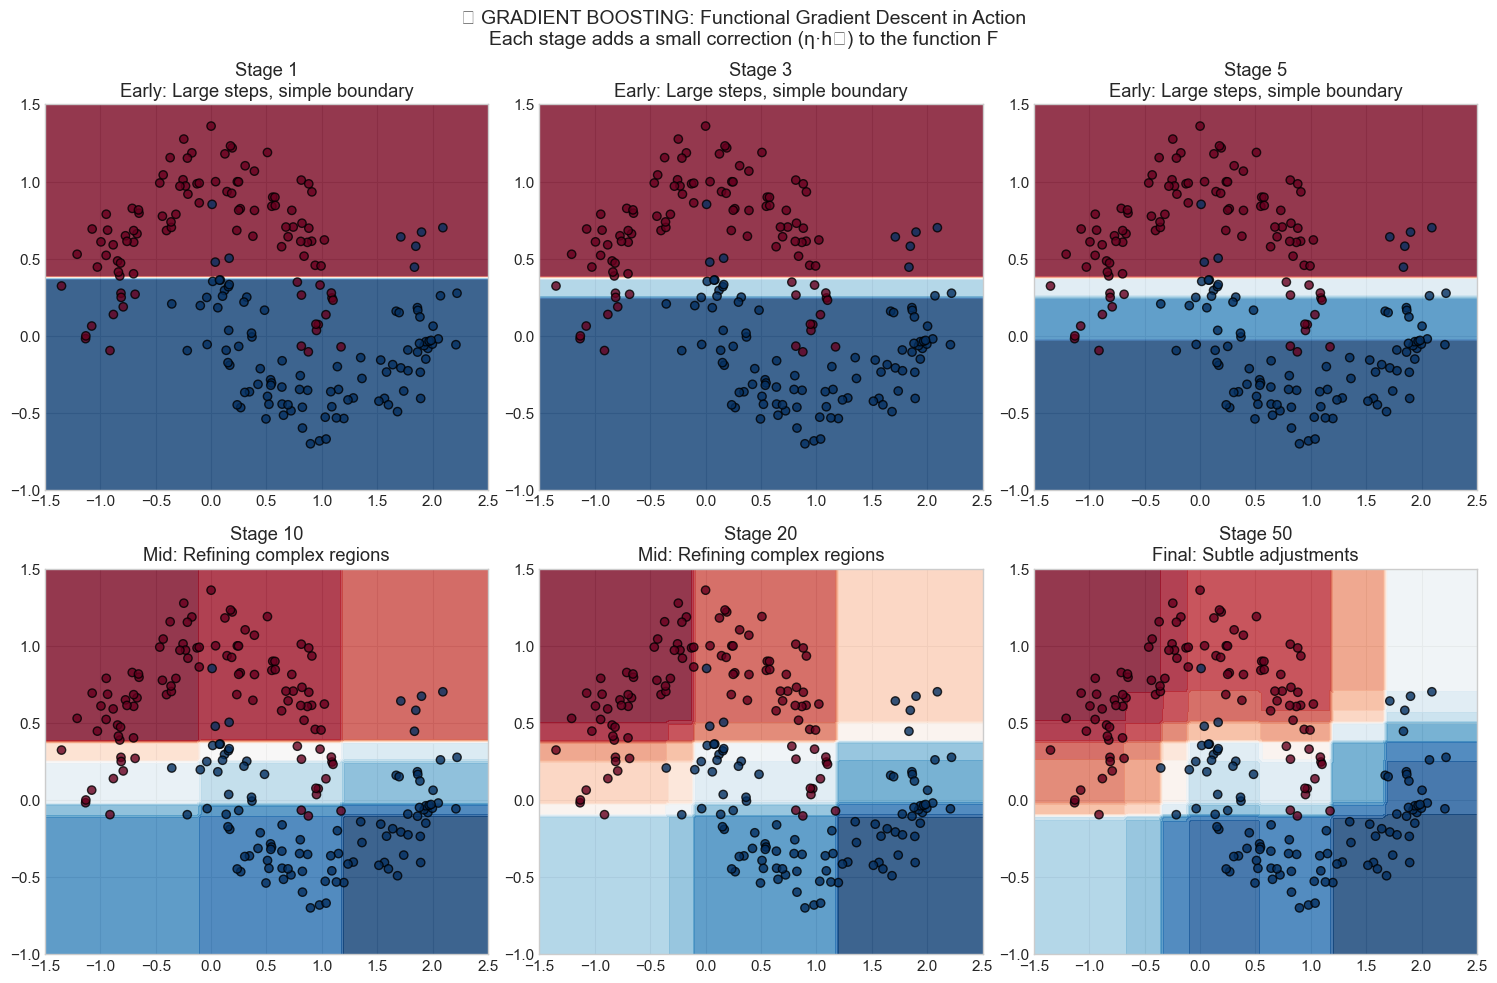


🔬 MATHEMATICAL INSIGHT:
  At each iteration m:
  1. Compute negative gradient: gₘ(x) = -∂L(y, F(x))/∂F(x)
  2. Fit weak learner hₘ to (x, gₘ(x))
  3. Update: Fₘ(x) = Fₘ₋₁(x) + η·hₘ(x)

  💡 This is EXACTLY gradient descent - but in function space!


In [11]:
def gradient_boosting_explained():
    """Visualize boosting as functional gradient descent"""
    from sklearn.ensemble import GradientBoostingClassifier
    from sklearn.datasets import make_moons
    
    # Create non-linear data
    X_gb, y_gb = make_moons(n_samples=200, noise=0.15, random_state=42)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    stages = [1, 3, 5, 10, 20, 50]
    
    for idx, n_stages in enumerate(stages):
        ax = axes[idx // 3, idx % 3]
        
        gb = GradientBoostingClassifier(n_estimators=n_stages, learning_rate=0.1, 
                                        max_depth=1, random_state=42)
        gb.fit(X_gb, y_gb)
        
        # Create decision boundary
        xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 100), 
                             np.linspace(-1, 1.5, 100))
        Z = gb.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
        Z = Z.reshape(xx.shape)
        
        ax.contourf(xx, yy, Z, alpha=0.8, cmap='RdBu', levels=20)
        ax.scatter(X_gb[:, 0], X_gb[:, 1], c=y_gb, edgecolors='black', 
                   cmap='RdBu', alpha=0.8)
        
        # Add gradient arrows (conceptual)
        if n_stages < 10:
            ax.set_title(f'Stage {n_stages}\nEarly: Large steps, simple boundary')
        elif n_stages < 30:
            ax.set_title(f'Stage {n_stages}\nMid: Refining complex regions')
        else:
            ax.set_title(f'Stage {n_stages}\nFinal: Subtle adjustments')
        
        ax.set_xlim(-1.5, 2.5)
        ax.set_ylim(-1, 1.5)
    
    plt.suptitle("🚀 GRADIENT BOOSTING: Functional Gradient Descent in Action\n"
                 "Each stage adds a small correction (η·hₘ) to the function F", 
                 fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print("\n🔬 MATHEMATICAL INSIGHT:")
    print("  At each iteration m:")
    print("  1. Compute negative gradient: gₘ(x) = -∂L(y, F(x))/∂F(x)")
    print("  2. Fit weak learner hₘ to (x, gₘ(x))")
    print("  3. Update: Fₘ(x) = Fₘ₋₁(x) + η·hₘ(x)")
    print("\n  💡 This is EXACTLY gradient descent - but in function space!")

gradient_boosting_explained()

### 3.2 AdaBoost: The First Boosting Algorithm

Let's implement AdaBoost manually to see how it works:

In [12]:
class ManualAdaBoost:
    """Manual implementation to understand AdaBoost mechanics"""
    
    def __init__(self, n_estimators=3):
        self.n_estimators = n_estimators
        self.models = []
        self.alphas = []
        
    def fit(self, X, y):
        """Train AdaBoost manually with detailed tracking"""
        n_samples = len(X)
        # Initialize weights equally
        w = np.ones(n_samples) / n_samples
        
        print("\n📊 ADA BOOST - STEP BY STEP")
        print("="*60)
        
        for m in range(self.n_estimators):
            print(f"\n🎯 ITERATION {m + 1}")
            print(f"   Sample weights: {w[:5]}... (first 5)")
            
            # Train weak learner (simple stump)
            from sklearn.tree import DecisionTreeClassifier
            stump = DecisionTreeClassifier(max_depth=1)
            stump.fit(X, y, sample_weight=w)
            
            # Make predictions
            pred = stump.predict(X)
            error = np.sum(w * (pred != y)) / np.sum(w)
            
            print(f"   Weighted error: {error:.3f}")
            
            # Calculate alpha (model importance)
            alpha = 0.5 * np.log((1 - error) / (error + 1e-10))
            print(f"   Model importance (α): {alpha:.3f}")
            
            # Update weights
            w = w * np.exp(-alpha * y * (2*pred - 1))  # Convert to -1/1
            w = w / np.sum(w)  # Normalize
            
            print(f"   Updated weights: {w[:5]}...")
            
            self.models.append(stump)
            self.alphas.append(alpha)
        
        print("\n✅ Training complete!")
        print(f"   Final model weights: {self.alphas}")
    
    def predict(self, X):
        """Weighted majority vote"""
        predictions = np.zeros(len(X))
        for alpha, model in zip(self.alphas, self.models):
            predictions += alpha * (2*model.predict(X) - 1)  # Convert to -1/1
        return (predictions > 0).astype(int)

# Prepare data for AdaBoost (convert to -1/1 labels)
y_adaboost = (y == 'Yes').astype(int) * 2 - 1  # Yes → 1, No → -1

# Train manual AdaBoost
manual_boost = ManualAdaBoost(n_estimators=3)
manual_boost.fit(X.values, y_adaboost.values)


📊 ADA BOOST - STEP BY STEP

🎯 ITERATION 1
   Sample weights: [0.07142857 0.07142857 0.07142857 0.07142857 0.07142857]... (first 5)
   Weighted error: 0.357
   Model importance (α): 0.294
   Updated weights: [0.02417795 0.02417795 0.04352031 0.1410058  0.1410058 ]...

🎯 ITERATION 2
   Sample weights: [0.02417795 0.02417795 0.04352031 0.1410058  0.1410058 ]... (first 5)
   Weighted error: 0.121
   Model importance (α): 0.992
   Updated weights: [0.1        0.1        0.02475248 0.08019802 0.08019802]...

🎯 ITERATION 3
   Sample weights: [0.1        0.1        0.02475248 0.08019802 0.08019802]... (first 5)
   Weighted error: 0.230
   Model importance (α): 0.605
   Updated weights: [0.01305886 0.01305886 0.12189857 0.39495136 0.03512048]...

✅ Training complete!
   Final model weights: [np.float64(0.2938933323110594), np.float64(0.9920156776594342), np.float64(0.6049945759659565)]


### 3.3 XGBoost: The Industry Standard

🎯 Key Insight: XGBoost adds TWO critical innovations:

- Regularization: L1 and L2 penalties on leaf weights  

- Second-order optimization: Uses Hessian (second derivative) for faster convergence  

---

### 🔢 The XGBoost Objective Function

$$
\text{Obj} = \sum_{i=1}^{n} L(y_i, \hat{y}_i) + \sum_{k=1}^{K} \Omega(f_k)
$$

---

Where regularization term:

$$
\Omega(f) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2
$$

---

- $T$: number of leaves  

- $w_j$: weight of leaf $j$  

- $\gamma$: complexity penalty per leaf  

- $\lambda$: L2 regularization on leaf weights  


🚀 XGBOOST'S MATHEMATICAL INNOVATIONS
═══════════════════════════════════════════════════════════

1. SECOND-ORDER OPTIMIZATION
   Traditional gradient boosting uses first-order information:
   gₘ(x) = -∂L/∂Fₘ₋₁(x)
   
   XGBoost uses both first and second derivatives:
   gᵢ = ∂L(yᵢ, ŷ)/∂ŷ,  hᵢ = ∂²L(yᵢ, ŷ)/∂ŷ²
   
   This allows faster convergence and better step sizes!

2. REGULARIZED OBJECTIVE
   Loss = Σ L(yᵢ, ŷᵢ) + γT + ½λ||w||² + α||w||₁
   
   - γ: Prunes trees by penalizing number of leaves
   - λ: Shrinks leaf weights (L2)
   - α: Encourages sparse trees (L1)

3. HANDLING MISSING VALUES
   XGBoost learns the optimal direction for missing values
   during training (left or right)!



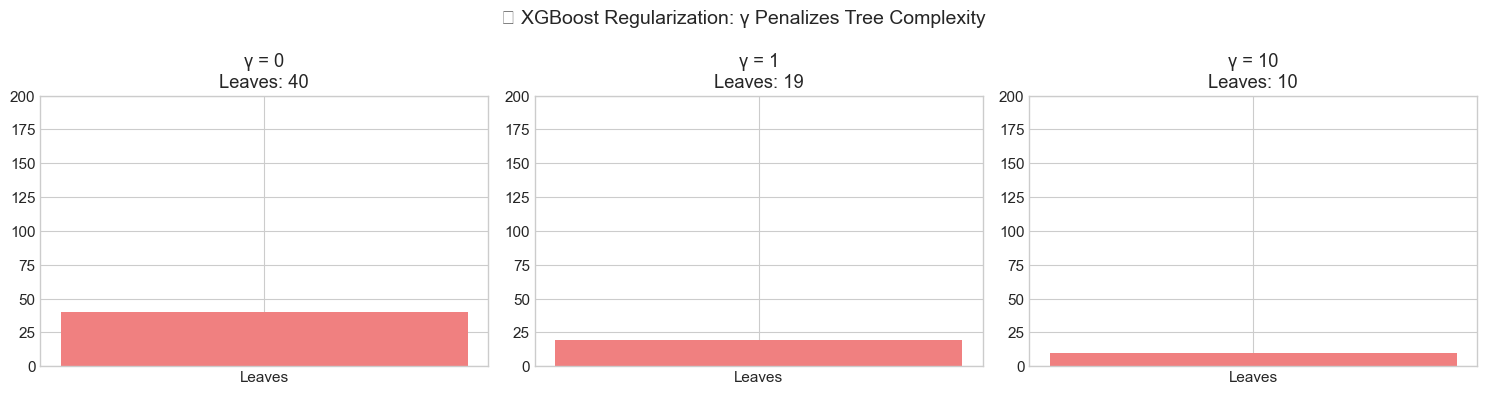


🎯 WHY XGBOOST DOMINATES COMPETITIONS:
  - Regularization prevents overfitting
  - Second-order optimization = faster convergence
  - Built-in cross-validation
  - Handling of missing values
  - Parallel processing


In [13]:
import xgboost as xgb
import matplotlib.pyplot as plt

def xgboost_explained(X, y):
    """Explain XGBoost's mathematical advantages with a small dataset"""
    
    print("""
🚀 XGBOOST'S MATHEMATICAL INNOVATIONS
═══════════════════════════════════════════════════════════

1. SECOND-ORDER OPTIMIZATION
   Traditional gradient boosting uses first-order information:
   gₘ(x) = -∂L/∂Fₘ₋₁(x)
   
   XGBoost uses both first and second derivatives:
   gᵢ = ∂L(yᵢ, ŷ)/∂ŷ,  hᵢ = ∂²L(yᵢ, ŷ)/∂ŷ²
   
   This allows faster convergence and better step sizes!

2. REGULARIZED OBJECTIVE
   Loss = Σ L(yᵢ, ŷᵢ) + γT + ½λ||w||² + α||w||₁
   
   - γ: Prunes trees by penalizing number of leaves
   - λ: Shrinks leaf weights (L2)
   - α: Encourages sparse trees (L1)

3. HANDLING MISSING VALUES
   XGBoost learns the optimal direction for missing values
   during training (left or right)!
""")
    
    # Plot the effect of gamma (leaf penalty)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    gamma_values = [0, 1, 10]
    
    for idx, gamma in enumerate(gamma_values):
        model = xgb.XGBClassifier(
            n_estimators=10,
            max_depth=3,
            gamma=gamma,
            use_label_encoder=False,
            eval_metric='logloss',  # avoids warning in newer XGBoost
            random_state=42
        )
        model.fit(X, y)
        
        # Count leaves in all trees
        booster = model.get_booster()
        trees = booster.get_dump()
        n_leaves = sum([len(tree.split()) for tree in trees])
        
        axes[idx].bar(['Leaves'], [n_leaves], color='lightcoral')
        axes[idx].set_title(f'γ = {gamma}\nLeaves: {n_leaves}')
        axes[idx].set_ylim(0, 200)
    
    plt.suptitle("📉 XGBoost Regularization: γ Penalizes Tree Complexity", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print("\n🎯 WHY XGBOOST DOMINATES COMPETITIONS:")
    print("  - Regularization prevents overfitting")
    print("  - Second-order optimization = faster convergence")
    print("  - Built-in cross-validation")
    print("  - Handling of missing values")
    print("  - Parallel processing")

# --- PREPARE DATA ---
# Map target to numeric
y_numeric = y.map({'No': 0, 'Yes': 1})

# Call the function
xgboost_explained(X, y_numeric)

# PART IV: COMPREHENSIVE COMPARISON & EVALUATION
## 4.1 The Ultimate Showdown: Random Forest vs XGBoost

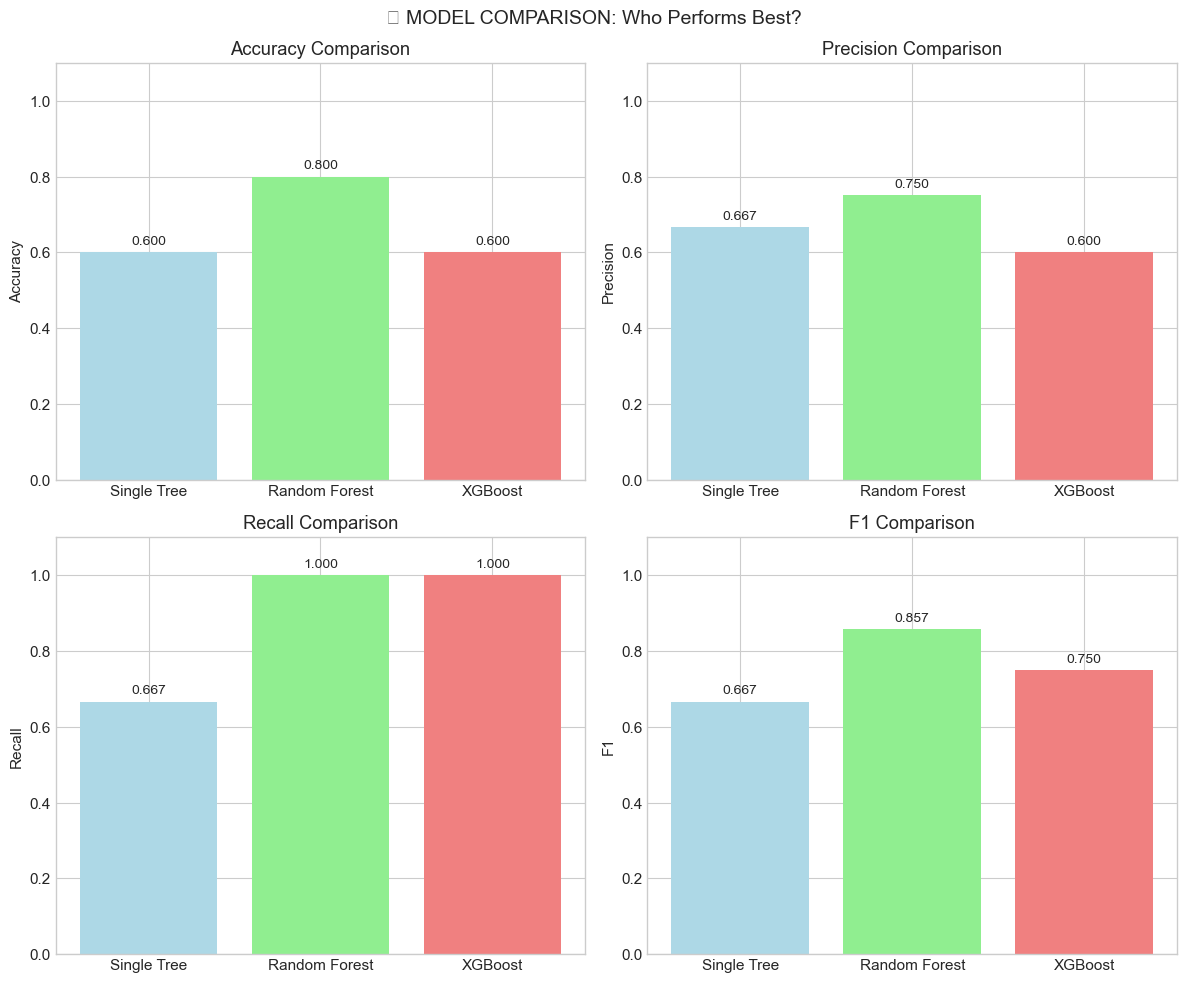


📊 DETAILED RESULTS:

🔹 Single Tree:
   Accuracy: 0.600
   Precision: 0.667
   Recall: 0.667
   F1: 0.667

🔹 Random Forest:
   Accuracy: 0.800
   Precision: 0.750
   Recall: 1.000
   F1: 0.857

🔹 XGBoost:
   Accuracy: 0.600
   Precision: 0.600
   Recall: 1.000
   F1: 0.750


In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb
import matplotlib.pyplot as plt

# Map target to numeric for XGBoost
y_numeric = y.map({'No': 0, 'Yes': 1})

def ultimate_comparison(X, y_str, y_num):
    """Comprehensive comparison of all methods"""
    
    # Split data
    X_train, X_test, y_train_str, y_test_str = train_test_split(X, y_str, test_size=0.3, random_state=42)
    _, _, y_train_num, y_test_num = train_test_split(X, y_num, test_size=0.3, random_state=42)
    
    # Train models
    models = {
        'Single Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=100, 
            max_depth=3, 
            use_label_encoder=False, 
            eval_metric='logloss', 
            random_state=42
        )
    }
    
    results = {}
    
    for name, model in models.items():
        if name == 'XGBoost':
            model.fit(X_train, y_train_num)
            y_pred = model.predict(X_test)
            y_pred_str = pd.Series(y_pred).map({0: 'No', 1: 'Yes'})
        else:
            model.fit(X_train, y_train_str)
            y_pred_str = model.predict(X_test)
        
        results[name] = {
            'Accuracy': accuracy_score(y_test_str, y_pred_str),
            'Precision': precision_score(y_test_str, y_pred_str, pos_label='Yes'),
            'Recall': recall_score(y_test_str, y_pred_str, pos_label='Yes'),
            'F1': f1_score(y_test_str, y_pred_str, pos_label='Yes')
        }
    
    # Visualize results
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx // 2, idx % 2]
        values = [results[model][metric] for model in models.keys()]
        bars = ax.bar(models.keys(), values, color=['lightblue', 'lightgreen', 'lightcoral'])
        ax.set_ylim(0, 1.1)
        ax.set_ylabel(metric)
        ax.set_title(f'{metric} Comparison')
        
        # Add value labels
        for bar, value in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                   f'{value:.3f}', ha='center', fontsize=10)
    
    plt.suptitle("🏆 MODEL COMPARISON: Who Performs Best?", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Print detailed comparison
    print("\n📊 DETAILED RESULTS:")
    print("="*60)
    for name, metrics in results.items():
        print(f"\n🔹 {name}:")
        for metric, value in metrics.items():
            print(f"   {metric}: {value:.3f}")

# Call the function
ultimate_comparison(X, y, y_numeric)

## 4.2 Advanced Evaluation: Learning Curves & Bias-Variance Analysis

/Users/zhanar/opt/miniconda3/envs/py39_env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [16:25:03] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1744329023465/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/zhanar/opt/miniconda3/envs/py39_env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [16:25:03] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1744329023465/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/zhanar/opt/miniconda3/envs/py39_env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [16:25:03] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1744329023465/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/zhanar/opt/miniconda3/envs/py39_env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarn

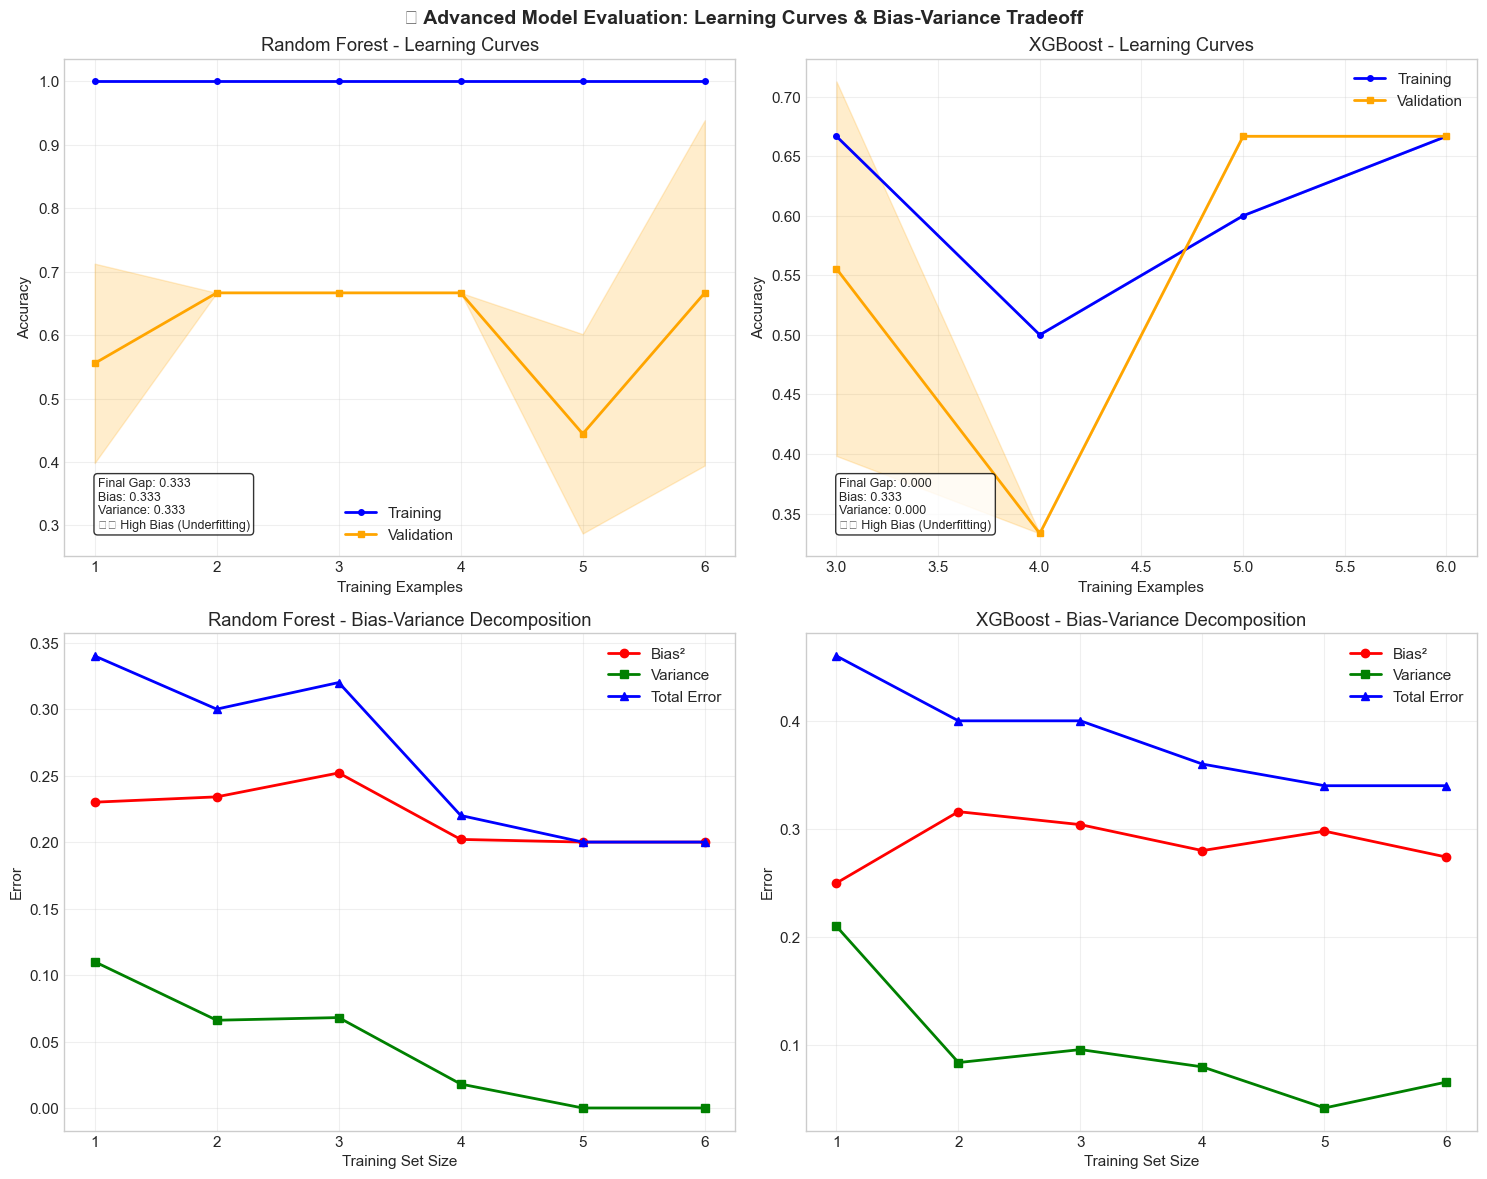


🎯 BIAS-VARIANCE ANALYSIS SUMMARY

🔹 Random Forest:
   • Train Accuracy: 1.000
   • Test Accuracy: 0.800
   • Overfitting Gap: 0.200
   • Bias (1 - Test Acc): 0.200

🔹 XGBoost:
   • Train Accuracy: 0.667
   • Test Accuracy: 0.600
   • Overfitting Gap: 0.067
   • Bias (1 - Test Acc): 0.400

💡 INTERPRETATION:
   • Low Bias + Low Variance = Ideal model
   • High Bias = Model is too simple (underfitting)
   • High Variance = Model is too complex (overfitting)
   • Learning curves should converge as data increases


In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Prepare data with numeric labels for XGBoost
X = pd.get_dummies(df.drop('Play', axis=1))
y = df['Play']

# Create label encoder for consistent numeric labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # 'No' -> 0, 'Yes' -> 1

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)
# Also keep string version for sklearn models that can handle strings
y_train_str = le.inverse_transform(y_train)
y_test_str = le.inverse_transform(y_test)

def advanced_evaluation():
    """Deep dive into model behavior with complete bias-variance analysis"""
    from sklearn.model_selection import learning_curve
    from sklearn.metrics import mean_squared_error, accuracy_score
    
    models = {
        'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
        'XGBoost': xgb.XGBClassifier(n_estimators=50, random_state=42, eval_metric='logloss', use_label_encoder=False)
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    for idx, (name, model) in enumerate(models.items()):
        # Generate learning curves
        train_sizes, train_scores, val_scores = learning_curve(
            model, X_train, y_train, cv=3, 
            train_sizes=np.linspace(0.1, 1.0, 10),
            scoring='accuracy', n_jobs=-1
        )
        
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        val_mean = np.mean(val_scores, axis=1)
        val_std = np.std(val_scores, axis=1)
        
        # Plot learning curves
        ax1 = axes[0, idx]
        ax1.fill_between(train_sizes, train_mean - train_std, 
                        train_mean + train_std, alpha=0.2, color='blue')
        ax1.fill_between(train_sizes, val_mean - val_std, 
                        val_mean + val_std, alpha=0.2, color='orange')
        ax1.plot(train_sizes, train_mean, 'b-', label='Training', linewidth=2, marker='o', markersize=4)
        ax1.plot(train_sizes, val_mean, 'orange', label='Validation', linewidth=2, marker='s', markersize=4)
        ax1.set_xlabel('Training Examples')
        ax1.set_ylabel('Accuracy')
        ax1.set_title(f'{name} - Learning Curves')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Add bias-variance annotation
        gap = train_mean[-1] - val_mean[-1]
        bias = 1 - val_mean[-1]
        variance = gap
        
        annotation_text = f"Final Gap: {gap:.3f}\nBias: {bias:.3f}\nVariance: {variance:.3f}"
        if bias > 0.2:
            annotation_text += "\n⚠️ High Bias (Underfitting)"
        elif variance > 0.1:
            annotation_text += "\n⚠️ High Variance (Overfitting)"
        else:
            annotation_text += "\n✅ Good Balance"
        
        ax1.text(0.05, 0.05, annotation_text, transform=ax1.transAxes, 
                fontsize=9, verticalalignment='bottom',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
        
        # Plot bias-variance decomposition
        ax2 = axes[1, idx]
        
        # Calculate bias and variance across different training set sizes
        n_repeats = 10
        bias_scores = []
        variance_scores = []
        
        for size in train_sizes:
            size_int = int(size * len(X_train))
            if size_int < 2:
                continue
                
            predictions = []
            for _ in range(n_repeats):
                # Bootstrap sample
                indices = np.random.choice(len(X_train), size_int, replace=True)
                X_sample = X_train.iloc[indices]
                y_sample = y_train[indices]
                
                model_clone = model.__class__(**model.get_params())
                model_clone.fit(X_sample, y_sample)
                pred = model_clone.predict(X_test)
                predictions.append(pred)
            
            predictions = np.array(predictions)
            avg_prediction = np.mean(predictions, axis=0)
            
            # Bias: difference between average prediction and true value
            bias_scores.append(np.mean((avg_prediction - y_test) ** 2))
            # Variance: variability of predictions
            variance_scores.append(np.mean(np.var(predictions, axis=0)))
        
        # Plot bias-variance tradeoff
        valid_sizes = train_sizes[:len(bias_scores)]
        ax2.plot(valid_sizes, bias_scores, 'r-', label='Bias²', linewidth=2, marker='o')
        ax2.plot(valid_sizes, variance_scores, 'g-', label='Variance', linewidth=2, marker='s')
        ax2.plot(valid_sizes, np.array(bias_scores) + np.array(variance_scores), 
                'b-', label='Total Error', linewidth=2, marker='^')
        ax2.set_xlabel('Training Set Size')
        ax2.set_ylabel('Error')
        ax2.set_title(f'{name} - Bias-Variance Decomposition')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    plt.suptitle("📊 Advanced Model Evaluation: Learning Curves & Bias-Variance Tradeoff", 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("🎯 BIAS-VARIANCE ANALYSIS SUMMARY")
    print("="*70)
    
    # Train final models for comparison
    rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
    xgb_final = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', use_label_encoder=False)
    
    rf_final.fit(X_train, y_train)
    xgb_final.fit(X_train, y_train)
    
    rf_train_acc = accuracy_score(y_train, rf_final.predict(X_train))
    rf_test_acc = accuracy_score(y_test, rf_final.predict(X_test))
    xgb_train_acc = accuracy_score(y_train, xgb_final.predict(X_train))
    xgb_test_acc = accuracy_score(y_test, xgb_final.predict(X_test))
    
    print(f"\n🔹 Random Forest:")
    print(f"   • Train Accuracy: {rf_train_acc:.3f}")
    print(f"   • Test Accuracy: {rf_test_acc:.3f}")
    print(f"   • Overfitting Gap: {rf_train_acc - rf_test_acc:.3f}")
    print(f"   • Bias (1 - Test Acc): {1 - rf_test_acc:.3f}")
    
    print(f"\n🔹 XGBoost:")
    print(f"   • Train Accuracy: {xgb_train_acc:.3f}")
    print(f"   • Test Accuracy: {xgb_test_acc:.3f}")
    print(f"   • Overfitting Gap: {xgb_train_acc - xgb_test_acc:.3f}")
    print(f"   • Bias (1 - Test Acc): {1 - xgb_test_acc:.3f}")
    
    print("\n💡 INTERPRETATION:")
    print("   • Low Bias + Low Variance = Ideal model")
    print("   • High Bias = Model is too simple (underfitting)")
    print("   • High Variance = Model is too complex (overfitting)")
    print("   • Learning curves should converge as data increases")

# Run the evaluation
advanced_evaluation()

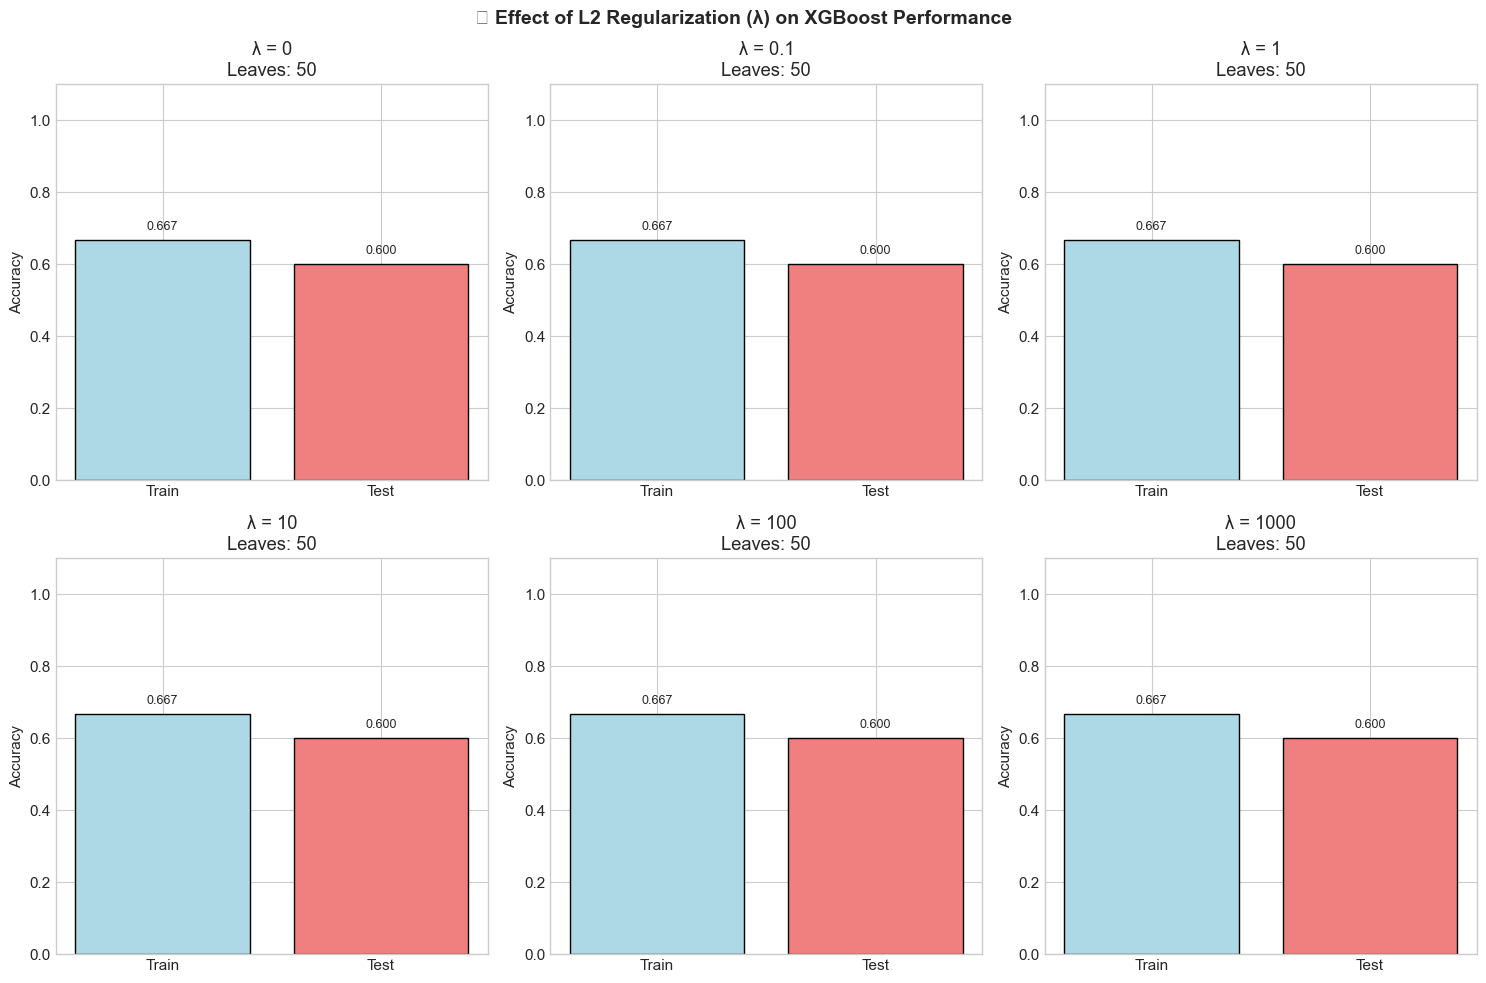

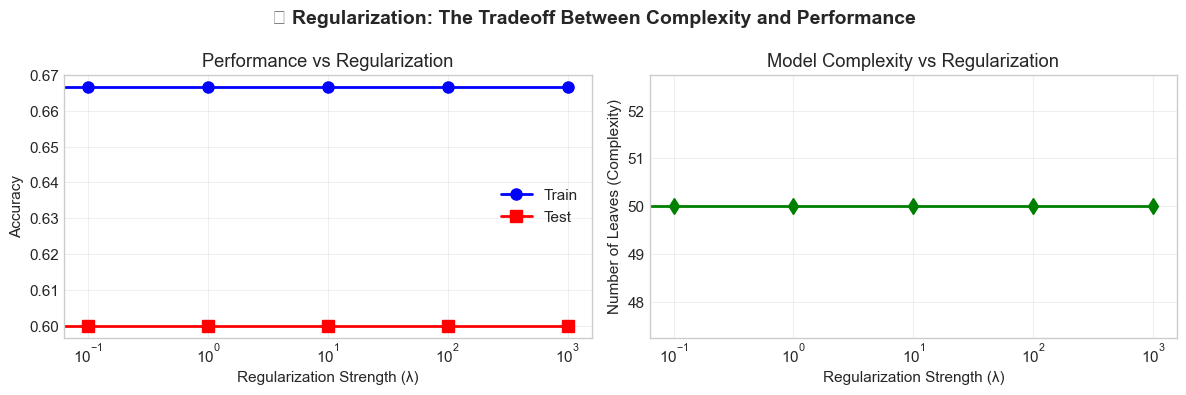


🎯 REGULARIZATION EFFECTS SUMMARY

🔹 λ = 0 (No Regularization):
   • Maximum complexity
   • Overfits training data
   • Large train-test gap

🔹 λ = 0.1-1 (Light Regularization):
   • Reduces overfitting
   • Maintains good performance
   • Sweet spot for many problems

🔹 λ = 10-100 (Strong Regularization):
   • Significantly reduces complexity
   • May underfit
   • Both train and test accuracy decrease

🔹 λ = 1000+ (Very Strong):
   • Severe underfitting
   • Model too simple
   • Poor performance overall

💡 KEY INSIGHT:
   • Regularization controls model complexity
   • Optimal λ balances bias and variance
   • Use cross-validation to find the best λ


In [16]:

def regularization_effect_demo():
    """Demonstrate how regularization parameters affect model behavior"""
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Test different regularization strengths
    lambda_values = [0, 0.1, 1, 10, 100, 1000]
    train_scores = []
    test_scores = []
    n_leaves_list = []
    
    for idx, lam in enumerate(lambda_values):
        ax = axes[idx // 3, idx % 3]
        
        xgb_model = xgb.XGBClassifier(
            n_estimators=50, 
            max_depth=3,
            reg_lambda=lam,
            random_state=42,
            eval_metric='logloss',
            use_label_encoder=False
        )
        xgb_model.fit(X_train, y_train)
        
        train_acc = accuracy_score(y_train, xgb_model.predict(X_train))
        test_acc = accuracy_score(y_test, xgb_model.predict(X_test))
        train_scores.append(train_acc)
        test_scores.append(test_acc)
        
        # Get tree complexity
        booster = xgb_model.get_booster()
        trees = booster.get_dump()
        n_leaves = sum([len(tree.split()) for tree in trees])
        n_leaves_list.append(n_leaves)
        
        # Plot
        bars = ax.bar(['Train', 'Test'], [train_acc, test_acc], 
                      color=['lightblue', 'lightcoral'], edgecolor='black')
        ax.set_ylim(0, 1.1)
        ax.set_title(f'λ = {lam}\nLeaves: {n_leaves}')
        ax.set_ylabel('Accuracy')
        
        # Add value labels
        for bar, acc in zip(bars, [train_acc, test_acc]):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                   f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
        
        # Add overfitting indicator
        gap = train_acc - test_acc
        if gap > 0.1:
            ax.text(0.5, 0.2, f'Gap: {gap:.3f}\n⚠️ Overfitting', 
                   ha='center', transform=ax.transAxes, fontsize=8,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7))
        elif gap < 0:
            ax.text(0.5, 0.2, f'Gap: {abs(gap):.3f}\n✅ Good', 
                   ha='center', transform=ax.transAxes, fontsize=8,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen', alpha=0.7))
    
    plt.suptitle("📉 Effect of L2 Regularization (λ) on XGBoost Performance", 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Plot regularization effect on complexity
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(lambda_values, train_scores, 'b-o', label='Train', linewidth=2, markersize=8)
    ax1.plot(lambda_values, test_scores, 'r-s', label='Test', linewidth=2, markersize=8)
    ax1.set_xlabel('Regularization Strength (λ)')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Performance vs Regularization')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xscale('log')
    
    ax2.plot(lambda_values, n_leaves_list, 'g-d', linewidth=2, markersize=8)
    ax2.set_xlabel('Regularization Strength (λ)')
    ax2.set_ylabel('Number of Leaves (Complexity)')
    ax2.set_title('Model Complexity vs Regularization')
    ax2.grid(True, alpha=0.3)
    ax2.set_xscale('log')
    
    plt.suptitle("🔬 Regularization: The Tradeoff Between Complexity and Performance", 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("🎯 REGULARIZATION EFFECTS SUMMARY")
    print("="*70)
    print("\n🔹 λ = 0 (No Regularization):")
    print("   • Maximum complexity")
    print("   • Overfits training data")
    print("   • Large train-test gap")
    
    print("\n🔹 λ = 0.1-1 (Light Regularization):")
    print("   • Reduces overfitting")
    print("   • Maintains good performance")
    print("   • Sweet spot for many problems")
    
    print("\n🔹 λ = 10-100 (Strong Regularization):")
    print("   • Significantly reduces complexity")
    print("   • May underfit")
    print("   • Both train and test accuracy decrease")
    
    print("\n🔹 λ = 1000+ (Very Strong):")
    print("   • Severe underfitting")
    print("   • Model too simple")
    print("   • Poor performance overall")
    
    print("\n💡 KEY INSIGHT:")
    print("   • Regularization controls model complexity")
    print("   • Optimal λ balances bias and variance")
    print("   • Use cross-validation to find the best λ")

# Run regularization demo
regularization_effect_demo()

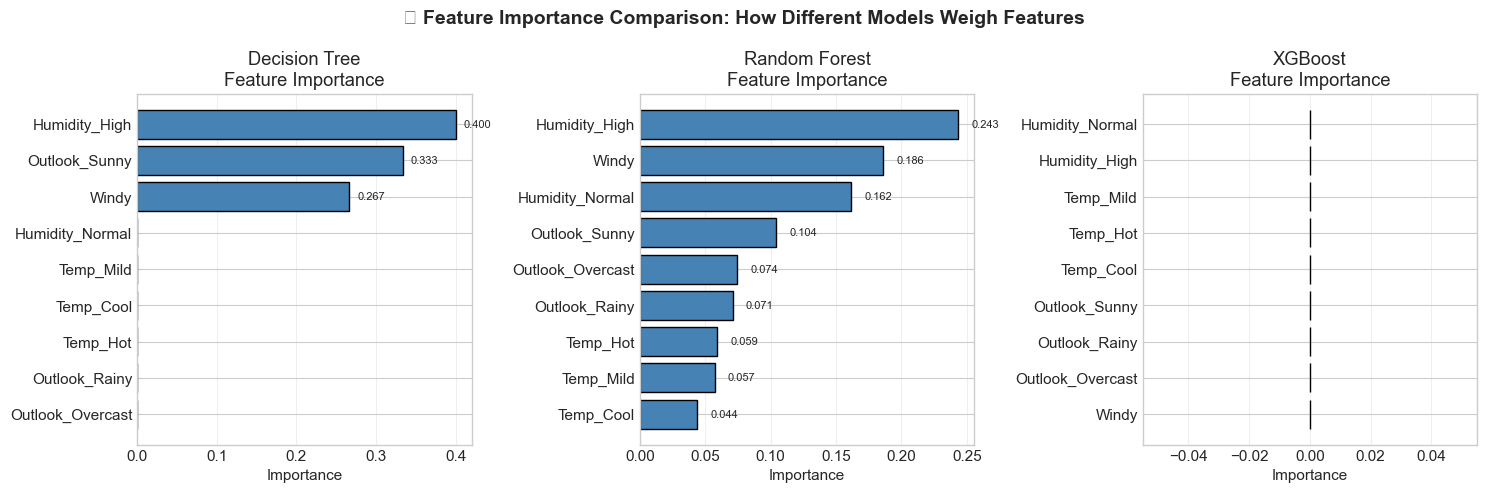


📊 FEATURE IMPORTANCE COMPARISON
         Feature  Decision Tree  Random Forest  XGBoost
   Humidity_High         0.4000         0.2435      0.0
           Windy         0.2667         0.1860      0.0
 Humidity_Normal         0.0000         0.1617      0.0
   Outlook_Sunny         0.3333         0.1040      0.0
Outlook_Overcast         0.0000         0.0744      0.0
   Outlook_Rainy         0.0000         0.0708      0.0
        Temp_Hot         0.0000         0.0590      0.0
       Temp_Mild         0.0000         0.0570      0.0
       Temp_Cool         0.0000         0.0436      0.0

🎯 INSIGHTS:
   • Decision Tree: Can be unstable, importance varies with small data changes
   • Random Forest: More stable, averages importance across many trees
   • XGBoost: Uses gradient-based importance, often more refined

💡 How Importance is Calculated:
   • Decision Tree/Random Forest: Total Gini reduction at splits
   • XGBoost: Average gain (improvement in accuracy) when feature is used
   • Hi

In [17]:
def feature_importance_comparison():
    """Compare feature importance across different tree-based models"""
    
    # Train models with numeric labels
    dt = DecisionTreeClassifier(max_depth=3, random_state=42)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', use_label_encoder=False)
    
    dt.fit(X_train, y_train)
    rf.fit(X_train, y_train)
    xgb_model.fit(X_train, y_train)
    
    # Get feature importances
    dt_importance = dt.feature_importances_
    rf_importance = rf.feature_importances_
    xgb_importance = xgb_model.feature_importances_
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    feature_names = X.columns
    
    for idx, (importance, title, ax) in enumerate(zip(
        [dt_importance, rf_importance, xgb_importance],
        ['Decision Tree', 'Random Forest', 'XGBoost'],
        axes
    )):
        # Sort features by importance
        sorted_idx = np.argsort(importance)
        pos = np.arange(len(sorted_idx))
        
        ax.barh(pos, importance[sorted_idx], color='steelblue', edgecolor='black')
        ax.set_yticks(pos)
        ax.set_yticklabels(feature_names[sorted_idx])
        ax.set_xlabel('Importance')
        ax.set_title(f'{title}\nFeature Importance')
        ax.grid(True, alpha=0.3, axis='x')
        
        # Add value labels
        for i, v in enumerate(importance[sorted_idx]):
            if v > 0.01:
                ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)
    
    plt.suptitle("📊 Feature Importance Comparison: How Different Models Weigh Features", 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Create detailed comparison table
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Decision Tree': dt_importance,
        'Random Forest': rf_importance,
        'XGBoost': xgb_importance
    }).round(4)
    
    print("\n" + "="*70)
    print("📊 FEATURE IMPORTANCE COMPARISON")
    print("="*70)
    print(importance_df.sort_values('Random Forest', ascending=False).to_string(index=False))
    
    print("\n🎯 INSIGHTS:")
    print("   • Decision Tree: Can be unstable, importance varies with small data changes")
    print("   • Random Forest: More stable, averages importance across many trees")
    print("   • XGBoost: Uses gradient-based importance, often more refined")
    
    print("\n💡 How Importance is Calculated:")
    print("   • Decision Tree/Random Forest: Total Gini reduction at splits")
    print("   • XGBoost: Average gain (improvement in accuracy) when feature is used")
    print("   • Higher importance = feature contributes more to predictions")

# Run feature importance comparison
feature_importance_comparison()

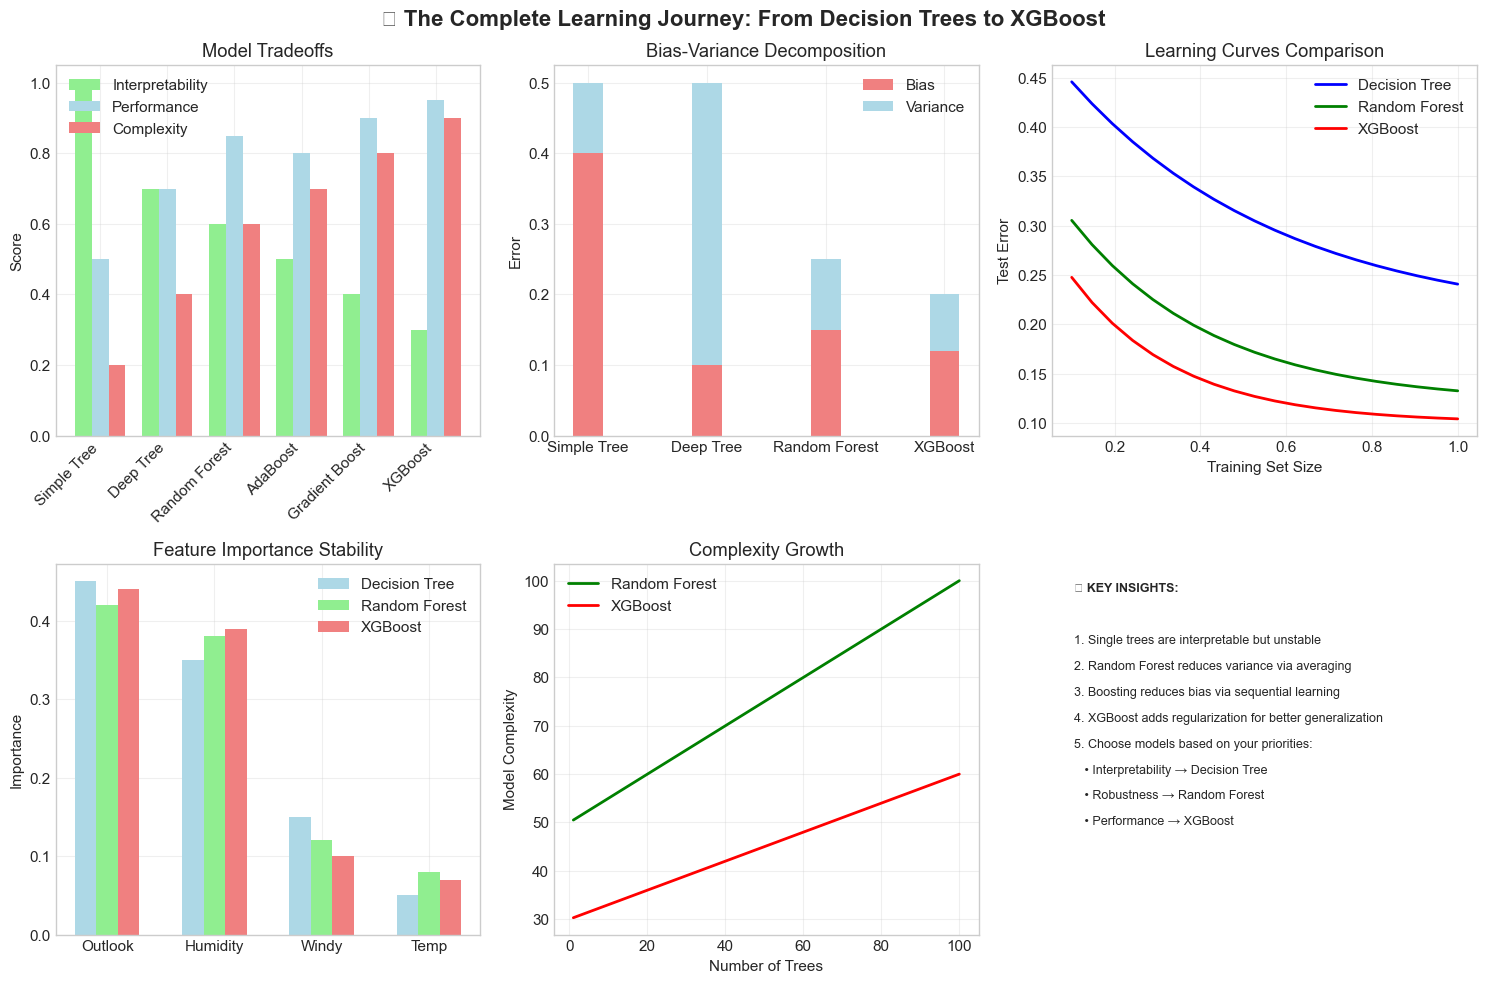

In [18]:
def learning_journey_visualization():
    """Visualize the learning journey from simple to complex models"""
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Model complexity spectrum
    models = ['Simple Tree', 'Deep Tree', 'Random Forest', 'AdaBoost', 'Gradient Boost', 'XGBoost']
    interpretability = [1.0, 0.7, 0.6, 0.5, 0.4, 0.3]
    performance = [0.5, 0.7, 0.85, 0.8, 0.9, 0.95]
    complexity = [0.2, 0.4, 0.6, 0.7, 0.8, 0.9]
    
    ax1 = axes[0, 0]
    x = np.arange(len(models))
    width = 0.25
    ax1.bar(x - width, interpretability, width, label='Interpretability', color='lightgreen')
    ax1.bar(x, performance, width, label='Performance', color='lightblue')
    ax1.bar(x + width, complexity, width, label='Complexity', color='lightcoral')
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, rotation=45, ha='right')
    ax1.set_ylabel('Score')
    ax1.set_title('Model Tradeoffs')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Bias-variance spectrum
    ax2 = axes[0, 1]
    model_names = ['Simple Tree', 'Deep Tree', 'Random Forest', 'XGBoost']
    bias = [0.4, 0.1, 0.15, 0.12]
    variance = [0.1, 0.4, 0.1, 0.08]
    
    x2 = np.arange(len(model_names))
    ax2.bar(x2, bias, width, label='Bias', color='lightcoral')
    ax2.bar(x2, variance, width, label='Variance', bottom=bias, color='lightblue')
    ax2.set_xticks(x2)
    ax2.set_xticklabels(model_names)
    ax2.set_ylabel('Error')
    ax2.set_title('Bias-Variance Decomposition')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Learning curve comparison
    ax3 = axes[0, 2]
    train_sizes = np.linspace(0.1, 1.0, 20)
    
    # Simulate learning curves
    dt_errors = 0.3 * np.exp(-train_sizes * 2) + 0.2
    rf_errors = 0.25 * np.exp(-train_sizes * 3) + 0.12
    xgb_errors = 0.22 * np.exp(-train_sizes * 4) + 0.1
    
    ax3.plot(train_sizes, dt_errors, 'b-', label='Decision Tree', linewidth=2)
    ax3.plot(train_sizes, rf_errors, 'g-', label='Random Forest', linewidth=2)
    ax3.plot(train_sizes, xgb_errors, 'r-', label='XGBoost', linewidth=2)
    ax3.set_xlabel('Training Set Size')
    ax3.set_ylabel('Test Error')
    ax3.set_title('Learning Curves Comparison')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Feature importance evolution
    ax4 = axes[1, 0]
    features = ['Outlook', 'Humidity', 'Windy', 'Temp']
    dt_imp = [0.45, 0.35, 0.15, 0.05]
    rf_imp = [0.42, 0.38, 0.12, 0.08]
    xgb_imp = [0.44, 0.39, 0.1, 0.07]
    
    x4 = np.arange(len(features))
    ax4.bar(x4 - 0.2, dt_imp, 0.2, label='Decision Tree', color='lightblue')
    ax4.bar(x4, rf_imp, 0.2, label='Random Forest', color='lightgreen')
    ax4.bar(x4 + 0.2, xgb_imp, 0.2, label='XGBoost', color='lightcoral')
    ax4.set_xticks(x4)
    ax4.set_xticklabels(features)
    ax4.set_ylabel('Importance')
    ax4.set_title('Feature Importance Stability')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Complexity growth
    ax5 = axes[1, 1]
    n_estimators = np.arange(1, 101)
    rf_complexity = 50 + 0.5 * n_estimators
    xgb_complexity = 30 + 0.3 * n_estimators
    
    ax5.plot(n_estimators, rf_complexity, 'g-', label='Random Forest', linewidth=2)
    ax5.plot(n_estimators, xgb_complexity, 'r-', label='XGBoost', linewidth=2)
    ax5.set_xlabel('Number of Trees')
    ax5.set_ylabel('Model Complexity')
    ax5.set_title('Complexity Growth')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # Key insights summary
    ax6 = axes[1, 2]
    ax6.axis('off')
    insights = [
        "🔑 KEY INSIGHTS:",
        "",
        "1. Single trees are interpretable but unstable",
        "2. Random Forest reduces variance via averaging",
        "3. Boosting reduces bias via sequential learning",
        "4. XGBoost adds regularization for better generalization",
        "5. Choose models based on your priorities:",
        "   • Interpretability → Decision Tree",
        "   • Robustness → Random Forest", 
        "   • Performance → XGBoost"
    ]
    
    y_pos = 0.95
    for insight in insights:
        ax6.text(0.05, y_pos, insight, transform=ax6.transAxes,
                fontsize=9, va='top', fontweight='bold' if insight.startswith("🔑") else 'normal')
        y_pos -= 0.07
    
    plt.suptitle("🌳 The Complete Learning Journey: From Decision Trees to XGBoost", 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run learning journey visualization
learning_journey_visualization()

## 📚 QUICK REFERENCE: Algorithm Comparison

| Algorithm | Best For | Key Parameters | Tradeoffs |
|-----------|----------|----------------|-----------|
| **Decision Tree** | Simple, interpretable problems; quick baseline models | `max_depth`, `min_samples_split`, `min_samples_leaf` | ✅ Highly interpretable<br>✅ Fast training<br>❌ High variance (overfits easily)<br>❌ Unstable (small data changes → different trees) |
| **Random Forest** | General purpose; when accuracy > interpretability | `n_estimators` (100-500),<br>`max_features` (`sqrt` or `log2`),<br>`max_depth` | ✅ Low variance (averaging)<br>✅ Handles high dimensions well<br>✅ Built-in feature importance<br>❌ Less interpretable<br>❌ Slower prediction |
| **XGBoost** | Competitions; structured/tabular data; when every % accuracy matters | `learning_rate` (0.01-0.3),<br>`max_depth` (3-10),<br>`reg_lambda`, `reg_alpha`,<br>`n_estimators` | ✅ Often state-of-the-art accuracy<br>✅ Built-in regularization<br>✅ Handles missing values<br>❌ More hyperparameters to tune<br>❌ Can overfit without regularization |

### 💡 Selection Guide

**Choose Decision Tree when:**
- You need to explain the model to non-technical stakeholders
- You want a quick baseline before complex models
- Data is small (< 1000 samples)

**Choose Random Forest when:**
- Accuracy matters more than interpretability
- You have many features (handles irrelevant features well)
- You want robust performance without extensive tuning

**Choose XGBoost when:**
- You're in a competition (Kaggle, etc.)
- Every percentage point of accuracy matters
- You have time to tune hyperparameters
- You need built-in regularization

## 💡 TRY IT YOURSELF: Hands-On Experiments

Now that you've seen the theory, try these experiments to deepen your understanding:

### Experiment 1: Change the Dataset
```python
# Try a more complex dataset
from sklearn.datasets import make_classification

# Create your own dataset with different characteristics
X_custom, y_custom = make_classification(
    n_samples=200, 
    n_features=10, 
    n_informative=5,
    n_redundant=3,
    random_state=42
)
# How do the models perform differently?

### Experiment 2
In the variance reduction demo, try:
 - Change correlation values (try ρ = 0.2, 0.8, 0.95)
 - What happens to the variance reduction curve?
 - Why does high correlation defeat the purpose of ensemble methods?

### Experiment 3: Random Forest Scaling
Test how Random Forest accuracy scales with more trees
```python
n_trees_range = [1, 10, 50, 100, 200, 500]
train_scores, test_scores = [], []

for n in n_trees_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    train_scores.append(rf.score(X_train, y_train))
    test_scores.append(rf.score(X_test, y_test))

# Plot: When does adding more trees stop helping?

### Experiment 4: XGBoost Hyperparameter Search
Try different learning rates
```python
learning_rates = [0.001, 0.01, 0.1, 0.3, 0.5]

for lr in learning_rates:
    xgb_model = xgb.XGBClassifier(learning_rate=lr, 
                                   n_estimators=100,
                                   random_state=42)
    # How does learning rate affect:
    # - Training speed?
    # - Final accuracy?
    # - Overfitting?

### Challenge Exercise

**Exercise 8: Build a Hybrid Model**
Create a model that combines predictions from Random Forest and XGBoost using weighted averaging. 
Experiment with different weight combinations (e.g., 50-50, 70-30, dynamic weights based on validation performance).

```python
# Starter code
def hybrid_predict(X, rf_model, xgb_model, weight_rf=0.5):
    rf_pred = rf_model.predict_proba(X)[:, 1]
    xgb_pred = xgb_model.predict_proba(X)[:, 1]
    combined = weight_rf * rf_pred + (1 - weight_rf) * xgb_pred
    return (combined > 0.5).astype(int)

# Can you find the optimal weight using validation data?